# 1. Import Libraries

In [1]:
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import spacy
from spacy.lang.en.stop_words import STOP_WORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from hdbscan import HDBSCAN
from umap import UMAP

# 2. Initial Settings

In [2]:
# Load the FCC news release dataset.
DATA_FILE = 'fcc_news_release_metadata_with_body_text.parquet'

df = pd.read_parquet(DATA_FILE)

In [3]:
# Create output folders and set the random seed.
OUTPUT_DIR = Path('outputs')
TABLE_DIR = OUTPUT_DIR / 'tables'
FIGURE_DIR = OUTPUT_DIR / 'figures'

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

TABLE_DIR, FIGURE_DIR

(WindowsPath('outputs/tables'), WindowsPath('outputs/figures'))

In [4]:
# A function to save a dataframe as a CSV table.
def save_table(dataframe, filename):
    path = TABLE_DIR / filename
    dataframe.to_csv(path, index=False, encoding="utf-8")

In [5]:
# A function to save the current plot as an image file.
def save_current_plot(filename):
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()

# 3. Exploratory Data Analysis

## 3.1. Data Quality Checks

In [6]:
# Check column names, data types and missing values.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3139 entries, 0 to 3138
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   page_title         3139 non-null   object        
 1   full_title         3139 non-null   object        
 2   document_type      3139 non-null   object        
 3   bureaus            3139 non-null   object        
 4   description        1567 non-null   object        
 5   webpage_url        3139 non-null   object        
 6   selected_txt_urls  3139 non-null   object        
 7   all_txt_urls       3139 non-null   object        
 8   all_txt_count      3139 non-null   int64         
 9   released_on        3139 non-null   datetime64[ns]
 10  issued_on          3139 non-null   datetime64[ns]
 11  adopted            806 non-null    datetime64[ns]
 12  filename           3139 non-null   object        
 13  body_text          3139 non-null   object        
 14  body_wor

In [7]:
# Use released_on as the main document date.
df['date'] = df['released_on'].fillna(df['issued_on'])
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Create time period columns for trend analysis.
df['year'] = df['date'].dt.year
df['quarter'] = df['date'].dt.to_period('Q').astype(str)
df['month'] = df['date'].dt.to_period('M').astype(str)

In [8]:
# Keep documents from 2010 to 2025.
df = df[df['year'].between(2010, 2025)].reset_index(drop=True)

In [9]:
# Create a quality check summary table.
qc_summary_dict = {
    'number_of_rows': df.shape[0],
    'number_of_columns': df.shape[1],
    'missing_body_text': df['body_text'].isna().sum(),
    'zero_body_word_count': (df['body_word_count'] == 0).sum(),
    'duplicate_filenames': df['filename'].duplicated().sum(),
    'body_word_count_mean': round(df['body_word_count'].mean()),
    'body_word_count_median': int(df['body_word_count'].median()),
    'body_word_count_max': int(df['body_word_count'].max()),
    'body_word_count_min': int(df['body_word_count'].min()),
    'min_data': df['date'].min(),
    'max_date': df['date'].max()
}

qc_summary = pd.DataFrame(
    qc_summary_dict.items(),
    columns=['metric', 'value']
)

save_table(qc_summary, 'quality_check_summary.csv')

qc_summary

,metric,value
0,number_of_rows,3073
1,number_of_columns,21
2,missing_body_text,0
3,zero_body_word_count,0
4,duplicate_filenames,0
5,body_word_count_mean,422
6,body_word_count_median,350
7,body_word_count_max,8115
8,body_word_count_min,25
9,min_data,2010-01-05 00:00:00


In [10]:
# Check text extraction methods.
df['extraction_method'].value_counts(dropna=False).rename('count').to_frame()

,count
extraction_method,
dateline,2126
city_prefix_without_date,800
content_after_front_matter,146
letter_salutation,1


In [11]:
# Check footer extraction methods.
df['footer_method'].value_counts(dropna=False).rename('count').to_frame()

,count
footer_method,
footer_marker,2959
no_footer_marker,93
commissioner_office_footer,17
trailing_media_contact,2
office_media_footer,1
inline_footer_marker,1


## 3.2. Explore Date Variables

In [12]:
def plot_doc_trend(summary_df, x_label, y_label, filename, tick_every=None):

    # Get period and value column names.
    cols = summary_df.columns
    period = cols[0]
    var = cols[1]

    # Count rows in the summary table.
    num_of_rows = len(summary_df)

    # Create x-axis positions.
    x_pos = range(num_of_rows)

    # Use every period label if tick frequency is not specified.
    if tick_every == None:
        tick_every = 1

     # Create the line plot.
    plt.figure(figsize=(10, 5))
    plt.plot(x_pos, summary_df[var])

    # Add plot title and axis labels.
    plt.title(f'{y_label} by {x_label}')
    plt.xlabel(x_label)
    plt.ylabel(y_label)

    # Select x-axis tick positions.
    tick_positions = list(range(0, num_of_rows, tick_every))

    # Add period labels to the x-axis.
    plt.xticks(
        tick_positions,
        summary_df[period].astype(str).iloc[tick_positions],
        rotation=45,
        ha='right'
    )

    # Adjust plot layout.
    plt.tight_layout()

    # Save and display the plot.
    save_current_plot(filename)
    
    plt.show()

In [13]:
# Summarize word counts by year.
word_stats_by_year = (
    df.groupby('year')['body_word_count']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .reset_index()
)

save_table(word_stats_by_year, 'word_stats_by_year.csv')

word_stats_by_year

,year,count,mean,median,min,max
0,2010,223,402.511211,344.0,39,2600
1,2011,161,466.180124,376.0,99,2811
2,2012,142,451.978873,387.0,69,1528
3,2013,134,445.276119,393.5,69,4072
4,2014,144,375.020833,343.0,86,1317
5,2015,141,406.319149,366.0,71,2229
6,2016,112,393.383929,370.0,49,899
7,2017,183,349.508197,307.0,48,2242
8,2018,192,374.531250,320.0,25,1452
9,2019,214,404.280374,353.0,126,1992


In [14]:
# Count documents by year, quarter and month.
doc_by_year = df.groupby('year').size().rename('n_documents').reset_index()
doc_by_quarter = df.groupby('quarter').size().rename('n_documents').reset_index()
doc_by_month = df.groupby('month').size().rename('n_documents').reset_index()

save_table(doc_by_year, 'number_of_documents_by_year.csv')
save_table(doc_by_quarter, 'number_of_documents_by_quarter.csv')
save_table(doc_by_month, 'number_of_documents_by_month.csv')

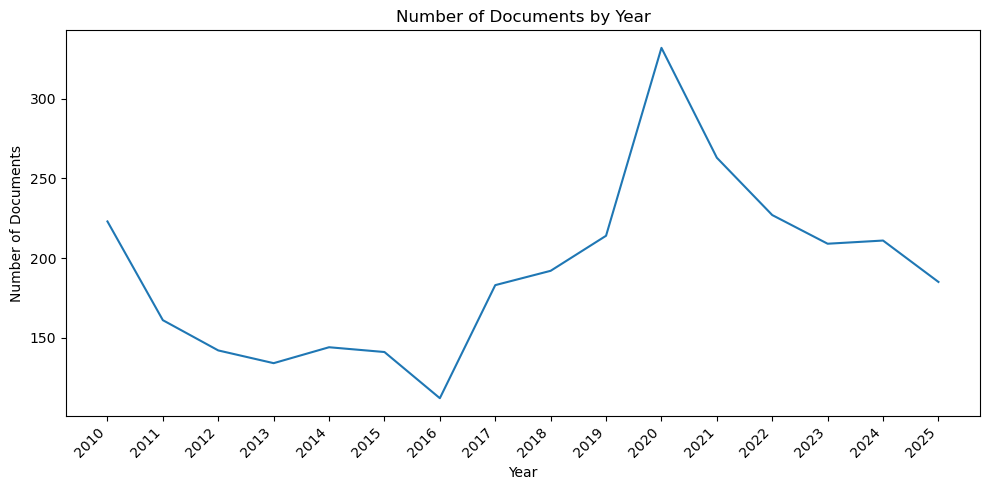

In [15]:
# Plot document counts by year, quarter and month.
plot_doc_trend(doc_by_year, 'Year', 'Number of Documents', 'number_of_documents_by_year.png')

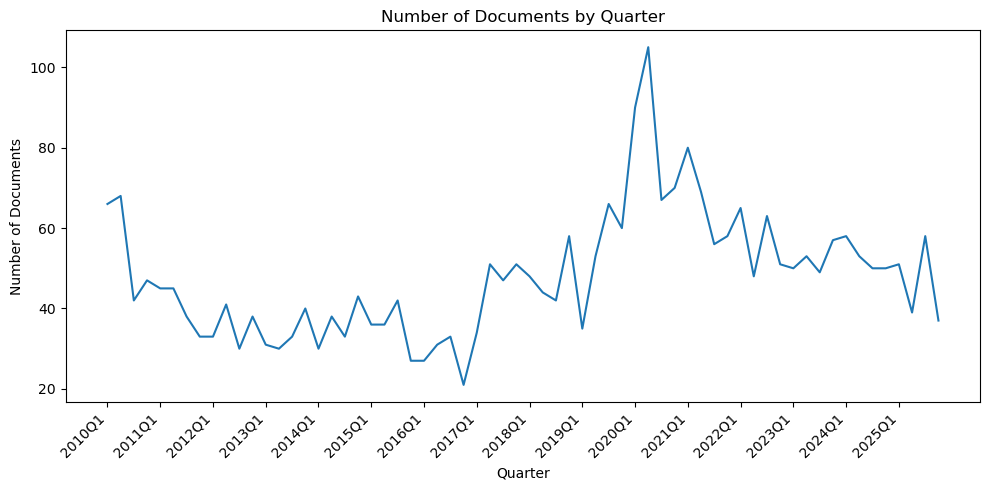

In [16]:
plot_doc_trend(doc_by_quarter, 'Quarter', 'Number of Documents', 'number_of_documents_by_quarter.png', 4)

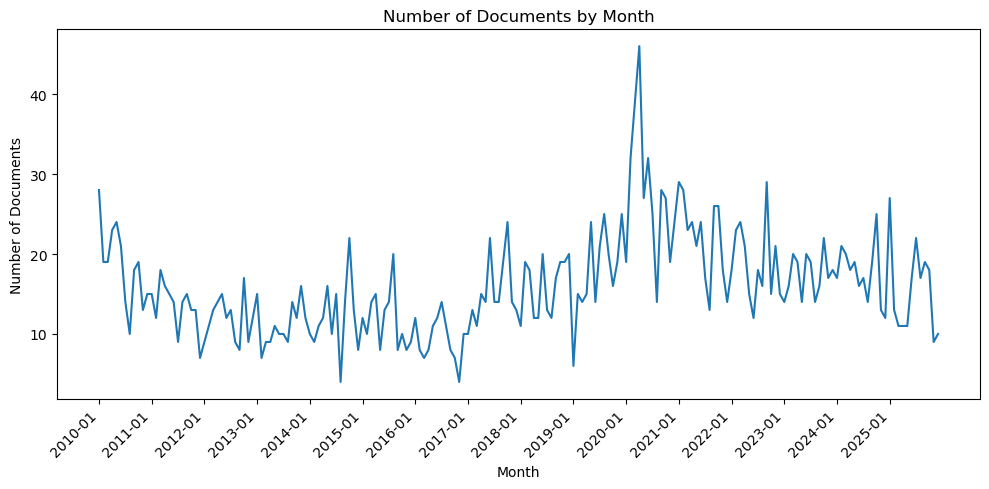

In [17]:
plot_doc_trend(doc_by_month, 'Month', 'Number of Documents', 'number_of_documents_by_month.png', 12)

In [18]:
# Calculate average word counts by year, quarter and month.
avg_words_by_year = df.groupby('year')['body_word_count'].mean().rename('avg_words_per_document').reset_index()
avg_words_by_quarter = df.groupby('quarter')['body_word_count'].mean().rename('avg_words_per_document').reset_index()
avg_words_by_month = df.groupby('month')['body_word_count'].mean().rename('avg_words_per_document').reset_index()

save_table(avg_words_by_year, 'average_number_of_words_by_year.csv')
save_table(avg_words_by_quarter, 'average_number_of_words_by_quarter.csv')
save_table(avg_words_by_month, 'average_number_of_words_by_month.csv')

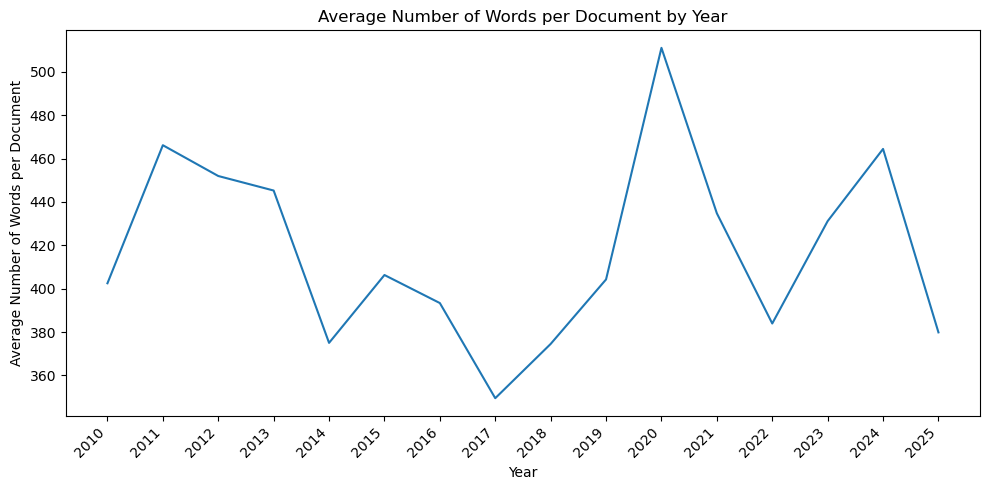

In [19]:
# Plot average word counts by year, quarter and month.
plot_doc_trend(avg_words_by_year, 'Year', 'Average Number of Words per Document', 'average_number_of_words_by_year.png')

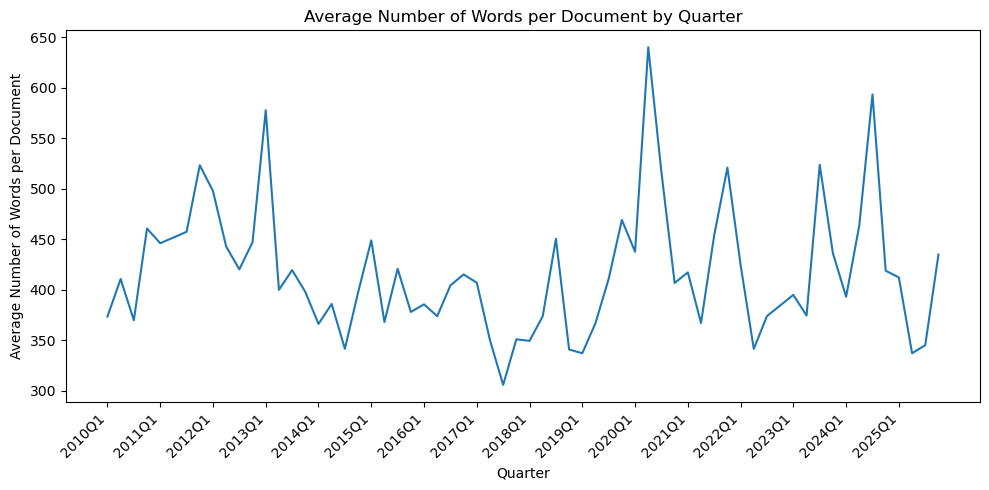

In [20]:
plot_doc_trend(avg_words_by_quarter, 'Quarter', 'Average Number of Words per Document', 'average_number_of_words_by_quarter.png', 4)

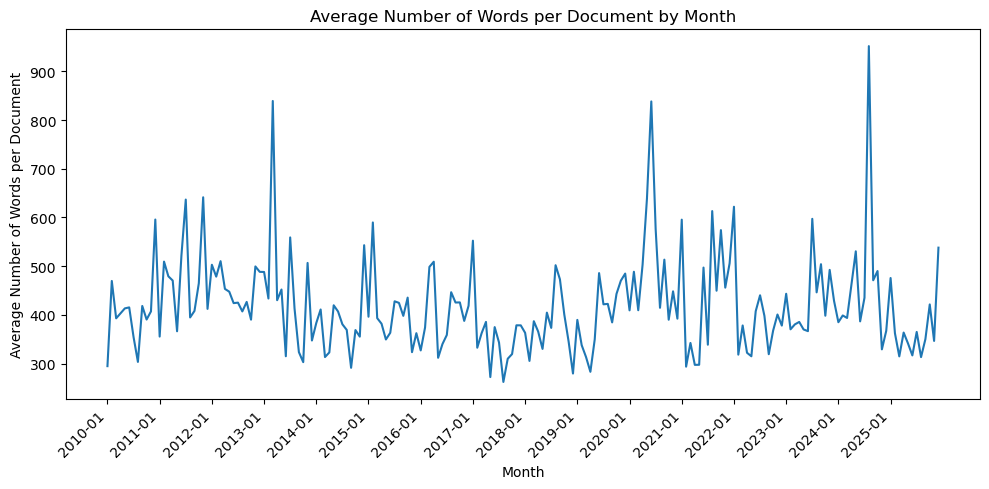

In [21]:
plot_doc_trend(avg_words_by_month, 'Month', 'Average Number of Words per Document', 'average_number_of_words_by_month.png', 12)

# 4. Text Preprocessing

## 4.1. Policy Dictionary and Technical-Term


### 4.1.1. Helper Functions

In [22]:
def clean_word(word):

    # Convert the word to lowercase text.
    word = str(word).lower().strip()
    
    # Remove characters except letters, numbers, underscores, and hyphens.
    word = re.sub(r'[^a-z0-9_-]', '', word)
    
    return word

In [23]:
def normalize_technical_phrases(text):

    # Return empty text for missing values.
    if pd.isna(text):
        return ''

    # Convert input to string.
    text = str(text)

    # Replace technical phrase patterns with normalized terms.
    for pattern, replacement in technical_phrase_patterns:
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)

    return text

In [24]:
def make_technical_terms(policy_dictionary):

    # Start with manually defined technical terms.
    terms = set(manual_technical_terms)

    # Add normalized replacement terms from technical phrase patterns.
    for _, replacement in technical_phrase_patterns:
        cleaned_replacement = clean_word(replacement)
        if cleaned_replacement:
            terms.add(cleaned_replacement)

    # Process terms from each policy dictionary category.
    for dictionary_terms in policy_dictionary.values():
        for term in dictionary_terms:

            # Normalize technical phrases in the dictionary term.
            normalized_term = normalize_technical_phrases(term)

            # Extract word pieces from the normalized term.
            for piece in re.findall(r'[A-Za-z0-9_/-]+', normalized_term):
                cleaned_piece = clean_word(piece)
                
                # Skip empty pieces.
                if not cleaned_piece:
                    continue

                # Set conditions to check whether the piece looks like a technical term.
                is_technical_like = (
                    cleaned_piece in manual_technical_terms
                    or '_' in cleaned_piece
                    or any(char.isdigit() for char in cleaned_piece)
                    or (piece.isupper() and len(cleaned_piece) <= 8)
                )

                # Add technical terms that are not stop words.
                if is_technical_like and cleaned_piece not in STOP_WORDS:
                    terms.add(cleaned_piece)

    # Return the technical term set.
    return terms

### 4.1.2. Setup Dictionary and Terms

In [25]:
# Define policy categories and dictionary terms.
policy_dictionary = {
    'accessibility': [
        'accessibility', 'accessibility clearinghouse', 'accessible emergency information',
        'american sign language', 'asl', 'audible crawl', 'audio description', 'captioning',
        'closed captioning', 'closed captioning display settings',
        'communications and video accessibility act', 'cvaa', 'disabilities', 'disability',
        'disability advisory committee', 'hearing aid compatibility', 'hearing aid compatible',
        'internet protocol captioned telephone service', 'ip cts', 'ip relay',
        'people with disabilities', 'real time text', 'real-time text', 'relay service', 'rtt',
        'telecommunications relay service', 'trs', 'tty', 'video description',
        'video relay service', 'video relay services', 'vrs',
    ],
    'affordability': [
        'a-cam', 'acp', 'affordable connectivity', 'affordable connectivity program',
        'affordable internet', 'broadband label', 'broadband labels',
        'broadband nutrition label', 'caf', 'connect america fund', 'consumer broadband label',
        'consumer broadband labels', 'ebb', 'eligible household',
        'emergency broadband benefit', 'emergency broadband benefit program', 'enhanced a-cam',
        'high cost', 'high cost support', 'household', 'lifeline', 'lifeline program',
        'low income', 'universal service', 'universal service fund', 'usf',
    ],
    'broadband': [
        'bdc', 'bead', 'broadband', 'broadband access', 'broadband data collection',
        'broadband deployment', 'broadband equity access and deployment', 'broadband internet',
        'broadband map', 'broadband mapping', 'broadband maps', 'broadband providers',
        'broadband service', 'broadband services', 'digital discrimination', 'digital divide',
        'digital equity', 'digital inclusion', 'high speed internet', 'internet access',
        'internet service', 'national broadband map', 'national broadband plan', 'rural areas',
        'rural broadband', 'tribal communities', 'tribal lands', 'tribal priority window',
    ],
    'compliance': [
        'apparent liability', 'citation', 'citation and order', 'civil penalty', 'compliance',
        'compliance plan', 'consent decree', 'enforcement', 'enforcement action',
        'field office', 'fine', 'fines', 'forfeiture', 'forfeiture order', 'fraud abuse',
        'investigation', 'investigations', 'nal', 'notice of apparent liability', 'penalty',
        'pirate act', 'pirate radio', 'preventing illegal radio abuse through enforcement act',
        'settlement', 'settlement agreement', 'unauthorized operation', 'violation',
        'violations', 'waste fraud abuse', 'waste fraud and abuse',
    ],
    'competition': [
        'acquisition', 'antitrust', 'broadband competition', 'business data services',
        'common carrier', 'competition', 'competitive', 'competitive bidding',
        'competitiveness', 'deregulation', 'deregulatory initiative', 'forbearance',
        'intercarrier compensation', 'interconnection', 'market power', 'merger',
        'merger review', 'net neutrality', 'north american numbering council',
        'number portability', 'numbering plan', 'numbering resources', 'obsolete rules',
        'open internet', 'open internet rules', 'outdated rules', 'paperwork reduction',
        'pole attachment', 'pole attachments', 'regulatory burdens', 'regulatory reform',
        'repeal', 'special access', 'technology transition', 'technology transitions',
        'toll free numbering', 'video marketplace', 'wireline competition',
    ],
    'media_broadcasting': [
        'am radio', 'am revitalization', 'atsc', 'atsc 3.0', 'broadcast', 'broadcast internet',
        'broadcast ownership', 'broadcast station', 'broadcast stations',
        'broadcast television', 'broadcaster', 'broadcasters', 'broadcasting', 'cable',
        'cable operator', 'cable operators', 'dbs', 'digital television',
        'direct broadcast satellite', 'dtv', 'eeo', 'equal employment opportunity',
        'fm booster', 'fm boosters', 'fm radio', 'fm translator', 'foreign sponsorship',
        'foreign sponsorship identification', 'local journalism', 'low power fm',
        'low power television', 'lpfm', 'lptv', 'media ownership',
        'multichannel video programming distributor', 'mvpd', 'next gen tv', 'nextgen tv',
        'quadrennial review', 'radio', 'radio station', 'retransmission consent', 'television',
        'television station', 'video programming', 'video programming distributor',
    ],
    'national_security': [
        'bgp', 'bgp routing', 'border gateway protocol', 'cable landing',
        'cable landing license', 'china mobile', 'china telecom', 'china unicom',
        'communications equipment', 'comnet', 'covered communications equipment',
        'covered equipment', 'covered list', 'covered list entities', 'cyber',
        'cyber security', 'cyber trust mark', 'cybersecurity',
        'cybersecurity labeling program', 'dahua', 'dji', 'equipment authorization',
        'equipment authorization process', 'equipment authorization program',
        'equipment authorization rules', 'foreign adversaries', 'foreign adversary',
        'foreign ownership', 'foreign ownership review', 'hikvision', 'huawei',
        'international section 214', 'iot labeling', 'iot labeling program', 'kaspersky',
        'national security', 'national security threat', 'network equipment',
        'pacific networks', 'rip and replace', 'section 214', 'section 214 authority',
        'section 214 authorization', 'section 214 authorizations',
        'secure and trusted communications networks', 'secure by design',
        'secure equipment act', 'secure networks act', 'submarine cable',
        'submarine cable landing', 'submarine cables', 'supply chain', 'supply chain risk',
        'supply chain security', 'team telecom', 'test lab', 'u.s. cyber trust mark', 'zte',
    ],
    'public_safety': [
        '911', '911 call', '911 calls', '911 service', '988', '988 lifeline',
        '988 suicide crisis lifeline', 'alerting', 'amber alert', 'amber alerts',
        'communications outage', 'communications outages', 'crisis lifeline', 'dirs',
        'disaster', 'disaster information reporting system', 'disaster response', 'disasters',
        'e911', 'eas', 'emergency alert', 'emergency alert system', 'emergency alerts',
        'emergency communications', 'emergency response', 'first responder',
        'first responders', 'integrated public alert and warning system', 'ipaws',
        'network outage', 'network outage reporting', 'network outage reporting system',
        'network resiliency', 'next generation 911', 'ng911', 'nors', 'outage', 'outages',
        'psap', 'public alert and warning', 'public safety', 'public safety answering point',
        'resilience', 'suicide crisis lifeline', 'suicide prevention lifeline', 'text 911',
        'text to 911', 'wea', 'wireless emergency alerts',
    ],
    'consumer_privacy': [
        'call blocking', 'caller id', 'caller id authentication', 'consumer privacy',
        'consumer protection', 'cpni', 'cramming', 'customer proprietary network information',
        'data breach', 'do not call', 'do not call registry', 'gateway provider',
        'gateway providers', 'illegal robocall', 'illegal robocalls', 'intermediate provider',
        'intermediate providers', 'junk fax', 'junk faxes', 'know your customer', 'kyc',
        'lead generator', 'lead generators', 'one-to-one consent',
        'personally identifiable information', 'pii', 'port-out fraud', 'privacy', 'robocall',
        'robocall mitigation', 'robocall mitigation database', 'robocalls', 'robotext',
        'robotexts', 'scam', 'scammer', 'scammers', 'scams', 'sim swapping', 'slamming',
        'spoofing', 'stir shaken', 'stir shaken caller id', 'stir/shaken', 'tcpa',
        'telephone consumer protection act', 'traced act', 'unwanted call', 'unwanted calls',
        'unwanted robocalls', 'voice service provider', 'voice service providers',
    ],
    'satellite_space': [
        'direct to cell', 'direct to device', 'earth station', 'earth stations',
        'fixed satellite service', 'fss', 'geostationary orbit', 'gso', 'leo',
        'low earth orbit', 'mobile satellite service', 'mss', 'ngso', 'ngso satellite',
        'non geostationary', 'non geostationary orbit', 'orbital debris', 'satellite',
        'satellite broadband', 'satellite communications', 'satellite service',
        'satellite services', 'satellite spectrum sharing', 'satellites', 'scs',
        'space based broadband', 'space bureau', 'space debris', 'space station',
        'space stations', 'supplemental coverage from space',
    ],
    'schools_libraries': [
        'campus', 'classroom', 'connected devices', 'e rate', 'e-rate', 'e-rate program',
        'ecf', 'emergency connectivity fund', 'emergency connectivity program',
        'funding for schools', 'libraries', 'schools', 'schools and libraries', 'student',
        'students', 'wi-fi hotspots', 'wifi hotspots',
    ],
    'spectrum_wireless': [
        '2.5 ghz', '3.45 ghz', '3.5 ghz', '4.9 ghz', '5.9 ghz', '12 ghz', '24 ghz', '5g',
        '5g fast plan', '5g fund', '5g fund for rural america', '6 ghz', '6g', 'auction',
        'aws', 'aws-3', 'c band', 'c-v2x', 'cbrs', 'citizens broadband radio service', 'ghz',
        'incentive auction', 'licensed spectrum', 'lte', 'mhz', 'mid band', 'millimeter wave',
        'mobile broadband', 'mobile service', 'mobile wireless', 'open radio access network',
        'open ran', 'radio access network', 'radio access networks', 'ran', 'shared spectrum',
        'spectrum', 'spectrum access', 'spectrum auction', 'spectrum license',
        'spectrum licenses', 'spectrum policy', 'spectrum sharing', 'tv white spaces', 'u-nii',
        'unlicensed devices', 'unlicensed spectrum', 'unlicensed use', 'v2x', 'wcs',
        'white space', 'white spaces', 'wi-fi', 'wifi', 'wifi 6', 'wireless',
        'wireless broadband', 'wireless communications', 'wireless service',
        'wireless services',
    ],
    'telehealth': [
        'clinic', 'connected care pilot program', 'covid-19 telehealth',
        'covid-19 telehealth program', 'health care', 'health provider', 'hospital', 'medical',
        'patient', 'patients', 'remote monitoring', 'rhc', 'rural health care',
        'rural health care program', 'telehealth', 'telehealth program',
    ]
}

In [26]:
# Summarize the number of terms in each policy category.
policy_dictionary_summary = pd.DataFrame({
    'policy_category': list(policy_dictionary.keys()),
    'n_terms': [len(terms) for terms in policy_dictionary.values()],
    'list_of_terms': [terms for terms in policy_dictionary.values()]
})

save_table(policy_dictionary_summary, 'policy_dictionary_summary.csv')

policy_dictionary_summary

,policy_category,n_terms,list_of_terms
0,accessibility,32,"[accessibility, accessibility clearinghouse, a..."
1,affordability,26,"[a-cam, acp, affordable connectivity, affordab..."
2,broadband,28,"[bdc, bead, broadband, broadband access, broad..."
3,compliance,30,"[apparent liability, citation, citation and or..."
4,competition,38,"[acquisition, antitrust, broadband competition..."
5,media_broadcasting,46,"[am radio, am revitalization, atsc, atsc 3.0, ..."
6,national_security,58,"[bgp, bgp routing, border gateway protocol, ca..."
7,public_safety,49,"[911, 911 call, 911 calls, 911 service, 988, 9..."
8,consumer_privacy,52,"[call blocking, caller id, caller id authentic..."
9,satellite_space,31,"[direct to cell, direct to device, earth stati..."


In [27]:
# Normalize multi-word policy phrases into single tokens.
technical_phrase_patterns = [
    (r'\bhigh[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+speed\s+internet\b', 'high_speed_internet'),
    (r'\bdigital\s+divide\b', 'digital_divide'),
    (r'\baffordable\s+connectivity\s+program\b', 'acp'),
    (r'\baffordable\s+connectivity\b', 'affordable_connectivity'),
    (r'\bemergency\s+connectivity\s+fund\b', 'ecf'),
    (r'\bemergency\s+connectivity\s+(program|funding)\b', 'emergency_connectivity'),
    (r'\bemergency\s+broadband\s+benefit(\s+program)?\b', 'ebb'),
    (r'\brural\s+digital\s+opportunity\s+fund\b', 'rdof'),
    (r'\bconnect\s+america\s+fund\b', 'caf'),
    (r'\benhanced\s+a[\s\-]*cam\b', 'enhanced_acam'),
    (r'\ba[\s\-]*cam\b', 'acam'),
    (r'\buniversal\s+service\s+fund\b', 'usf'),
    (r'\blifeline\s+program\b', 'lifeline_program'),
    (r'\brural\s+health\s+care(\s+program)?\b', 'rhc'),
    (r'\bcovid[\s\-]*19\s+telehealth\s+program\b', 'covid_telehealth'),
    (r'\btelehealth\s+program\b', 'telehealth_program'),
    (r'\bconnected\s+care\s+pilot\s+program\b', 'connected_care_pilot'),
    (r'\bbroadband\s+equity\s+access\s+and\s+deployment\b', 'bead'),
    (r'\bbroadband\s+data\s+collection\b', 'bdc'),
    (r'\bbroadband\s+deployment\b', 'broadband_deployment'),
    (r'\bbroadband\s+services?\b', 'broadband_service'),
    (r'\bbroadband\s+internet\b', 'broadband_internet'),
    (r'\bbroadband\s+providers?\b', 'broadband_provider'),
    (r'\bnational\s+broadband\s+plan\b', 'national_broadband_plan'),
    (r'\bnational\s+broadband\s+map\b', 'broadband_map'),
    (r'\bbroadband\s+maps?\b', 'broadband_map'),
    (r'\bbroadband\s+mapping\b', 'broadband_map'),
    (r'\b(consumer\s+)?broadband\s+(nutrition\s+)?labels?\b', 'broadband_label'),
    (r'\be[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]*rate(\s+program)?\b', 'e_rate'),
    (r'\bhigh[\s\-]*cost\s+(program|support)?\b', 'high_cost'),
    (r'\bdigital\s+equity\b', 'digital_equity'),
    (r'\bdigital\s+inclusion\b', 'digital_inclusion'),
    (r'\bdigital\s+discrimination\b', 'digital_discrimination'),
    (r'\btribal\s+priority\s+window\b', 'tribal_priority_window'),
    (r'\btribal\s+lands?\b', 'tribal_land'),
    (r'\bpole\s+attachments?\b', 'pole_attachment'),
    (r'\b5\s*g\s+fund(\s+for\s+rural\s+america)?\b', '5g_fund'),
    (r'\b5\s*g\b', '5_g'),
    (r'\b6\s*g\b', '6_g'),
    (r'\bwi[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]*fi\s*6\b', 'wifi_6'),
    (r'\bwi[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]*fi\b', 'wifi'),
    (r'\bmid[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+band\b', 'mid_band'),
    (r'\bc[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+band\b', 'c_band'),
    (r'\b2\.5\s*ghz(\s+band)?\b', '2_5_ghz'),
    (r'\b3\.45\s*ghz(\s+band)?\b', '3_45_ghz'),
    (r'\b3\.5\s*ghz(\s+band)?\b', '3_5_ghz'),
    (r'\b4\.9\s*ghz(\s+band)?\b', '4_9_ghz'),
    (r'\b5\.9\s*ghz(\s+band)?\b', '5_9_ghz'),
    (r'\b6\s*ghz(\s+band)?\b', '6_ghz'),
    (r'\b12\s*ghz(\s+band)?\b', '12_ghz'),
    (r'\b24\s*ghz(\s+band)?\b', '24_ghz'),
    (r'\bmillimeter\s+wave\b', 'millimeter_wave'),
    (r'\bmobile\s+broadband\b', 'mobile_broadband'),
    (r'\bwireless\s+broadband\b', 'wireless_broadband'),
    (r'\bwireless\s+communications\b', 'wireless_communications'),
    (r'\bmobile\s+wireless\b', 'mobile_wireless'),
    (r'\bmobile\s+service\b', 'mobile_service'),
    (r'\bcitizens\s+broadband\s+radio\s+service\b', 'cbrs'),
    (r'\btv\s+white\s+spaces?\b', 'tv_white_space'),
    (r'\bwhite\s+spaces?\b', 'white_space'),
    (r'\bopen[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+ran\b', 'open_ran'),
    (r'\bopen\s+radio\s+access\s+networks?\b', 'open_ran'),
    (r'\bradio\s+access\s+networks?\b', 'radio_access_network'),
    (r'\baws[\s\-]*3\b', 'aws_3'),
    (r'\bu[\s\-]*nii\b', 'u_nii'),
    (r'\bc[\s\-]*v2x\b', 'c_v2x'),
    (r'\bcellular\s+vehicle\s+to\s+everything\b', 'c_v2x'),
    (r'\bvehicle\s+to\s+everything\b', 'v2x'),
    (r'\bsatellite\s+services?\b', 'satellite_service'),
    (r'\bsatellite\s+communications\b', 'satellite_communications'),
    (r'\bsatellite\s+broadband\b', 'satellite_broadband'),
    (r'\bspace\s+bureau\b', 'space_bureau'),
    (r'\blow[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+earth\s+orbit\b', 'leo'),
    (r'\bnon[\s\-]*geostationary\s+orbit\b', 'ngso'),
    (r'\bnon[\s\-]*geostationary\b', 'non_geostationary'),
    (r'\bgeostationary\s+orbit\b', 'gso'),
    (r'\bfixed[\s\-]*satellite\s+service\b', 'fss'),
    (r'\bmobile\s+satellite\s+service\b', 'mss'),
    (r'\bearth\s+stations?\b', 'earth_station'),
    (r'\bspace\s+stations?\b', 'space_station'),
    (r'\bdirect[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+to[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+device\b', 'direct_to_device'),
    (r'\bdirect\s+to\s+device\b', 'direct_to_device'),
    (r'\bdirect[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+to[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+cell\b', 'direct_to_cell'),
    (r'\bdirect\s+to\s+cell\b', 'direct_to_cell'),
    (r'\bsupplemental\s+coverage\s+from\s+space\b', 'scs'),
    (r'\bspace[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+based\s+broadband\b', 'space_based_broadband'),
    (r'\bspace[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+based\b', 'space_based'),
    (r'\borbital\s+debris\b', 'orbital_debris'),
    (r'\bspace\s+debris\b', 'space_debris'),
    (r'\bstir[\s/\-]+shaken\b', 'stir_shaken'),
    (r'\bshaken[\s/\-]+stir\b', 'stir_shaken'),
    (r'\bdo\s+not\s+call(\s+registry)?\b', 'do_not_call'),
    (r'\bcaller\s+id\b', 'caller_id'),
    (r'\btelephone\s+consumer\s+protection\s+act\b', 'tcpa'),
    (r'\brobocall\s+mitigation\s+database\b', 'robocall_mitigation_database'),
    (r'\brobocall\s+mitigation\b', 'robocall_mitigation'),
    (r'\bvoice\s+service\s+providers?\b', 'voice_service_provider'),
    (r'\bgateway\s+providers?\b', 'gateway_provider'),
    (r'\bintermediate\s+providers?\b', 'intermediate_provider'),
    (r'\bknow[\s\-]*your[\s\-]*customer\b', 'kyc'),
    (r'\bone[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+to[\s\-\u2010\u2011\u2012\u2013\u2014\u2212]+one\s+consent\b', 'one_to_one_consent'),
    (r'\blead\s+generators?\b', 'lead_generator'),
    (r'\btraced\s+act\b', 'traced_act'),
    (r'\bsim\s+swapping\b', 'sim_swapping'),
    (r'\bport[\s\-]*out\s+fraud\b', 'port_out_fraud'),
    (r'\bcustomer\s+proprietary\s+network\s+information\b', 'cpni'),
    (r'\bpersonally\s+identifiable\s+information\b', 'pii'),
    (r'\bdata\s+breach(?:es)?\b', 'data_breach'),
    (r'\bunwanted\s+calls?\b', 'unwanted_call'),
    (r'\bincarcerated\s+people[^\w]+s\s+communications\s+services\b', 'ipcs'),
    (r'\bincarcerated\s+people\s+communications\s+services\b', 'ipcs'),
    (r'\binmate\s+calling\s+services?\b', 'ics'),
    (r'\bnext\s+generation\s+911\b', 'ng911'),
    (r'\bng\s*[\-]?\s*911\b', 'ng911'),
    (r'\be\s*[\-]?\s*911\b', 'e911'),
    (r'\btext\s+to\s+911\b', 'text_to_911'),
    (r'\bwireless\s+emergency\s+alerts\b', 'wea'),
    (r'\bemergency\s+alert\s+system\b', 'eas'),
    (r'\bpublic\s+safety\s+answering\s+point\b', 'psap'),
    (r'\bdisaster\s+information\s+reporting\s+system\b', 'dirs'),
    (r'\bintegrated\s+public\s+alert\s+and\s+warning\s+system\b', 'ipaws'),
    (r'\bpublic\s+alert\s+and\s+warning\b', 'public_alert_warning'),
    (r'\bnetwork\s+outage\s+reporting\s+system\b', 'nors'),
    (r'\bnetwork\s+outage\s+reporting\b', 'network_outage_reporting'),
    (r'\bnetwork\s+outages?\b', 'network_outage'),
    (r'\bcommunications\s+outages?\b', 'communications_outage'),
    (r'\bemergency\s+communications\b', 'emergency_communications'),
    (r'\bemergency\s+response\b', 'emergency_response'),
    (r'\bdisaster\s+response\b', 'disaster_response'),
    (r'\bfirst\s+responders?\b', 'first_responder'),
    (r'\bamber\s+alerts?\b', 'amber_alert'),
    (r'\b988\s+suicide\s+crisis\s+lifeline\b', '988_lifeline'),
    (r'\b988\s+lifeline\b', '988_lifeline'),
    (r'\bsuicide\s+crisis\s+lifeline\b', '988_lifeline'),
    (r'\bsuicide\s+prevention\s+lifeline\b', 'suicide_prevention_lifeline'),
    (r'\bfm\s+radio\b', 'fm_radio'),
    (r'\bam\s+radio\b', 'am_radio'),
    (r'\bam\s+revitalization\b', 'am_revitalization'),
    (r'\bfm\s+translator\b', 'fm_translator'),
    (r'\bfm\s+boosters?\b', 'fm_booster'),
    (r'\blow\s+power\s+television\b', 'lptv'),
    (r'\blow\s+power\s+tv\b', 'lptv'),
    (r'\blow\s+power\s+fm\b', 'lpfm'),
    (r'\bmultichannel\s+video\s+programming\s+distributor\b', 'mvpd'),
    (r'\bdirect\s+broadcast\s+satellite\b', 'dbs'),
    (r'\bnext[\s\-]*gen\s+tv\b', 'nextgen_tv'),
    (r'\bnextgen\s+tv\b', 'nextgen_tv'),
    (r'\batsc\s*3\.0\b', 'atsc_3_0'),
    (r'\bdigital\s+television\b', 'dtv'),
    (r'\bbroadcast\s+internet\b', 'broadcast_internet'),
    (r'\bquadrennial\s+review\b', 'quadrennial_review'),
    (r'\bforeign\s+sponsorship\s+identification\b', 'foreign_sponsorship'),
    (r'\bequal\s+employment\s+opportunity\b', 'eeo'),
    (r'\bvideo\s+relay\s+services?\b', 'vrs'),
    (r'\btelecommunications\s+relay\s+service\b', 'trs'),
    (r'\binternet\s+protocol\s+captioned\s+telephone\s+service\b', 'ip_cts'),
    (r'\bip[\s\-]+cts\b', 'ip_cts'),
    (r'\bip\s+relay\b', 'ip_relay'),
    (r'\bhearing\s+aid\s+compatibility\b', 'hearing_aid_compatibility'),
    (r'\bhearing\s+aid\s+compatible\b', 'hearing_aid_compatible'),
    (r'\bclosed\s+captioning\s+display\s+settings\b', 'closed_captioning_display'),
    (r'\bclosed\s+captioning\b', 'closed_captioning'),
    (r'\baudio\s+description\b', 'audio_description'),
    (r'\bvideo\s+description\b', 'video_description'),
    (r'\baudible\s+crawl\b', 'audible_crawl'),
    (r'\baccessible\s+emergency\s+information\b', 'accessible_emergency_information'),
    (r'\bcommunications\s+and\s+video\s+accessibility\s+act\b', 'cvaa'),
    (r'\bamerican\s+sign\s+language\b', 'asl'),
    (r'\breal[\s\-]*time\s+text\b', 'rtt'),
    (r'\brip\s+and\s+replace\b', 'rip_and_replace'),
    (r'\bsecure\s+and\s+trusted\s+communications\s+networks\b', 'secure_trusted_networks'),
    (r'\bsecure\s+networks\s+act\b', 'secure_networks_act'),
    (r'\bsecure\s+equipment\s+act\b', 'secure_equipment_act'),
    (r'\bcyber\s+security\b', 'cybersecurity'),
    (r'\bcovered\s+communications\s+equipment\b', 'covered_communications_equipment'),
    (r'\bcommunications\s+equipment\b', 'communications_equipment'),
    (r'\bcovered\s+equipment\b', 'covered_equipment'),
    (r'\bcovered\s+list\s+entities\b', 'covered_list'),
    (r'\bcovered\s+list\b', 'covered_list'),
    (r'\bequipment\s+authorization\s+program\b', 'equipment_authorization_program'),
    (r'\bequipment\s+authorization\s+(process|rules)\b', 'equipment_authorization'),
    (r'\bchina\s+telecom\b', 'china_telecom'),
    (r'\bchina\s+mobile\b', 'china_mobile'),
    (r'\bchina\s+unicom\b', 'china_unicom'),
    (r'\bpacific\s+networks\b', 'pacific_networks'),
    (r'\binternational\s+section\s+214\b', 'international_section_214'),
    (r'\bsection\s+214\b', 'section_214'),
    (r'\bteam\s+telecom\b', 'team_telecom'),
    (r'\bforeign\s+ownership\s+review\b', 'foreign_ownership_review'),
    (r'\bforeign\s+ownership\b', 'foreign_ownership'),
    (r'\bsubmarine\s+cable\s+landing\s+licenses?\b', 'submarine_cable_landing_license'),
    (r'\bsubmarine\s+cable\s+landing\b', 'submarine_cable_landing'),
    (r'\bsubmarine\s+cables?\b', 'submarine_cable'),
    (r'\bcable\s+landing\s+licenses?\b', 'cable_landing_license'),
    (r'\bcable\s+landing\b', 'cable_landing'),
    (r'\bcyber\s+trust\s+mark\b', 'cyber_trust_mark'),
    (r'\bu\.?s\.?\s+cyber\s+trust\s+mark\b', 'cyber_trust_mark'),
    (r'\binternet\s+of\s+things\b', 'iot'),
    (r'\biot\s+(cybersecurity\s+)?labeling(\s+program)?\b', 'iot_labeling'),
    (r'\bcybersecurity\s+labeling\s+program\b', 'iot_labeling'),
    (r'\bartificial\s+intelligence\b', 'ai'),
    (r'\bai[\s\-]*generated\b', 'ai_generated'),
    (r'\bunmanned\s+aircraft\s+systems\b', 'uas'),
    (r'\bborder\s+gateway\s+protocol\b', 'bgp'),
    (r'\bbgp\s+routing\b', 'bgp_routing'),
    (r'\bnotice\s+of\s+apparent\s+liability\b', 'nal'),
    (r'\benforcement\s+action\b', 'enforcement_action'),
    (r'\bfield\s+office\b', 'field_office'),
    (r'\bnotice\s+of\s+violation\b', 'notice_of_violation'),
    (r'\bcitation\s+and\s+order\b', 'citation_order'),
    (r'\bconsent\s+decree\b', 'consent_decree'),
    (r'\bpirate\s+radio\b', 'pirate_radio'),
    (r'\bpirate\s+act\b', 'pirate_act'),
    (r'\bwaste\s+fraud\s+and\s+abuse\b', 'waste_fraud_abuse'),
    (r'\bwaste\s+fraud\s+abuse\b', 'waste_fraud_abuse'),
    (r'\bopen\s+internet\b', 'open_internet'),
    (r'\bnet\s+neutrality\b', 'net_neutrality'),
    (r'\bmerger\s+review\b', 'merger_review'),
    (r'\bbusiness\s+data\s+services\b', 'business_data_services'),
    (r'\bintercarrier\s+compensation\b', 'intercarrier_compensation'),
    (r'\btechnology\s+transitions?\b', 'technology_transition'),
    (r'\bnumber\s+portability\b', 'number_portability'),
    (r'\bnorth\s+american\s+numbering\s+council\b', 'nanc'),
    (r'\bnumbering\s+resources\b', 'numbering_resources'),
    (r'\btoll\s+free\s+numbering\b', 'toll_free_numbering'),
    (r'\bderegulatory\s+initiative\b', 'deregulatory_initiative'),
    (r'\boutdated\s+rules\b', 'outdated_rules'),
    (r'\bobsolete\s+rules\b', 'obsolete_rules'),
    (r'\bcall\s+blocking\b', 'call_blocking')
]

In [28]:
# Technical tokens to preserve before preprocessing.
manual_technical_terms = {
    '2_5_ghz', '3_45_ghz', '3_5_ghz', '4_9_ghz', '5_9_ghz',
    '5_g', '5g', '5g_fund', '6_ghz', '6_g', '6g', '12_ghz', '24_ghz',
    '911', '988', '988_lifeline', 'acp', 'acam', 'accessibility',
    'affordable_connectivity', 'ai', 'ai_generated', 'am_radio',
    'am_revitalization', 'amber_alert', 'asl', 'atsc',
    'atsc_3_0', 'auction', 'audible_crawl', 'aws', 'aws_3', 'bdc', 'bead',
    'bgp', 'bgp_routing', 'broadcast', 'broadcaster', 'broadcasting',
    'broadband', 'broadband_deployment', 'broadband_internet',
    'broadband_label', 'broadband_map', 'broadband_provider',
    'broadband_service', 'burdensome', 'business_data_services', 'c_band', 'c_v2x', 'cable', 'cable_landing',
    'cable_landing_license', 'caf', 'caller_id', 'captioning', 'cbrs', 'closed_captioning',
    'closed_captioning_display', 'communications_equipment',
    'communications_outage', 'competition', 'connected_care_pilot',
    'consent_decree', 'covered_communications_equipment', 'covered_equipment',
    'covered_list', 'covid_telehealth', 'cpni', 'cvaa', 'cyber',
    'cyber_trust_mark', 'cybersecurity', 'data_breach', 'dahua', 'dbs',
    'digital_discrimination', 'digital_divide', 'digital_equity',
    'deregulatory_initiative', 'digital_inclusion', 'direct_to_cell', 'direct_to_device', 'dirs',
    'disability', 'dji', 'do_not_call', 'dtv', 'e_rate', 'e911', 'eas', 'ebb', 'ecf', 'eeo',
    'emergency_communications', 'emergency_connectivity', 'emergency_response',
    'enforcement', 'enforcement_action', 'enhanced_acam',
    'equipment_authorization', 'equipment_authorization_program', 'field_office',
    'first_responder', 'fm_booster', 'fm_radio', 'fm_translator', 'foreign_ownership',
    'foreign_ownership_review', 'foreign_sponsorship', 'forfeiture', 'fraud',
    'fss', 'gso', 'ghz', 'hearing_aid_compatibility', 'hearing_aid_compatible',
    'high_cost', 'high_speed_internet', 'hikvision', 'huawei', 'ics', 'iot',
    'iot_labeling', 'ip_cts', 'ip_relay', 'ipaws', 'ipcs', 'kaspersky', 'kyc',
    'lead_generator', 'leo', 'lifeline', 'lifeline_program', 'lpfm', 'lptv',
    'lte', 'merger_review', 'mhz', 'mid_band', 'millimeter_wave', 'mobile_broadband',
    'mobile_service', 'mobile_wireless', 'mss', 'mvpd',
    'nal', 'nanc', 'net_neutrality', 'network_outage', 'network_outage_reporting',
    'ng911', 'ngso', 'non_geostationary', 'nors', 'notice_of_violation',
    'number_portability', 'numbering_resources', 'one_to_one_consent',
    'obsolete_rules', 'open_internet', 'open_ran', 'orbit', 'orbital_debris',
    'outdated_rules', 'pacific_networks',
    'penalty', 'pii', 'pirate_act', 'pirate_radio', 'pole_attachment', 'port_out_fraud', 'psap',
    'public_alert_warning', 'quadrennial_review', 'radio', 'radio_access_network',
    'ran', 'rdof', 'rhc', 'rip_and_replace', 'robocall', 'robocall_mitigation',
    'robocall_mitigation_database', 'robotext', 'rtt', 'scs', 'section_214',
    'secure_equipment_act', 'secure_networks_act', 'secure_trusted_networks',
    'sim_swapping', 'satellite', 'satellite_broadband', 'satellite_communications',
    'satellite_service', 'scam', 'space', 'space_based', 'space_based_broadband',
    'space_bureau', 'space_debris', 'space_station', 'spectrum', 'spoofing',
    'stir_shaken', 'submarine_cable', 'submarine_cable_landing',
    'submarine_cable_landing_license', 'suicide_prevention_lifeline',
    'tcpa', 'team_telecom', 'telehealth', 'telehealth_program', 'television',
    'text_to_911', 'toll_free_numbering', 'traced_act', 'tribal_land',
    'tribal_priority_window', 'trs', 'tty', 'tv_white_space', 'uas', 'u_nii',
    'uhf', 'unwanted_call', 'usac', 'usf', 'v2x', 'vhf', 'violation',
    'voice_service_provider', 'vrs', 'waste_fraud_abuse', 'wcs', 'wea',
    'white_space', 'wifi', 'wifi_6', 'wireless', 'wireless_broadband',
    'wireless_communications', 'zte'
}

In [29]:
# Define POS filters and domain-specific stopwords.
allowed_pos = {'NOUN', 'ADJ', 'VERB'}

domain_stopwords = {
    'fcc', 'federal', 'communication', 'commission',
    'commissioner', 'chairman', 'chairwoman', 'today',
    'announce', 'release', 'statement', 'order', 'rule',
    'rulemaking', 'notice', 'propose', 'proposal', 'adopt',
    'action', 'docket', 'document', 'information', 'background',
    'additional', 'separate', 'approve', 'issue', 'bureau',
    'office', 'media', 'contact', 'washington', 'dc', 'us', 'united', 'state',
    'january', 'february', 'march', 'april', 'may', 'june',
    'july', 'august', 'september', 'october', 'november', 'december',
    'am', 'pm'
}

In [30]:
# Create the final technical term list.
technical_terms = make_technical_terms(policy_dictionary)

technical_terms_df = pd.DataFrame({
    'technical_term': sorted(technical_terms)
})

save_table(technical_terms_df, 'technical_termns.csv')

technical_terms_df

,technical_term
0,12_ghz
1,24_ghz
2,2_5_ghz
3,3_45_ghz
4,3_5_ghz
...,...
258,wifi_6
259,wireless
260,wireless_broadband
261,wireless_communications


## 4.2. Preprocessing the Body Text

In [31]:
# Load the English spaCy model.
# 1) Keep the tagger and lemmatizer for POS filtering and lemmatization.
# 2) Disable parser and NER: they are not needed for basic preprocessing.

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

text_lengths = df['body_text'].astype(str).str.len()
nlp.max_length = max(nlp.max_length, 3000000)

nlp.pipe_names

['tok2vec', 'tagger', 'attribute_ruler', 'lemmatizer']

In [32]:
def preprocess_doc(doc):
    
    tokens = []

    for token in doc:

        # formatting and punctuation tokens
        if token.is_space or token.is_punct or token.is_quote or token.is_bracket:
            continue
        # remove URLs and emails first
        if token.like_url or token.like_email:
            continue

        token_text = clean_word(token.text)

        # preserve important technical tokens 
        if token_text in technical_terms:
            tokens.append(token_text)
            continue

        # remove common or non-topic tokens
        if token.is_stop or token.like_num:
            continue
        # keep only selected parts of speech (pos)
        if token.pos_ not in allowed_pos:
            continue

        lemma = clean_word(token.lemma_)

        if len(lemma) < 2:
            continue
        if lemma in domain_stopwords:
            continue

        tokens.append(lemma)

    return tokens

In [33]:
# Normalize technical phrases in document body text.
df['normalized_body_text'] = df['body_text'].map(normalize_technical_phrases)

# Convert normalized body text into a list.
texts = df['normalized_body_text'].tolist()

# Create container to store document tokens.
tokens = []

# Process documents with spaCy.
for doc in tqdm(nlp.pipe(texts, batch_size=32), total=len(texts)):

    # Store preprocessed tokens for each document.
    tokens.append(preprocess_doc(doc))

# Store token lists.
df['tokens'] = tokens

# Join tokens into cleaned text and count tokens in each document.
df['clean_text'] = df['tokens'].map(lambda tokens: ' '.join(tokens))
df['token_count'] = df['tokens'].map(len)

  0%|          | 0/3073 [00:00<?, ?it/s]

In [34]:
# Preview the cleaned text output.
df[['filename', 'page_title', 
    'date', 'year', 'quarter', 
    'body_word_count', 'body_text', 
    'token_count', 'clean_text']]

,filename,page_title,date,year,quarter,body_word_count,body_text,token_count,clean_text
0,251223_Chairman_Carr_Highlights_Wins_Delivered...,Chairman Carr Highlights Wins Delivered in 2025,2025-12-23,2025,2025Q4,2257,"Today, Chairman Carr summarized some of the FC...",1058,summarize key win historic year proud win able...
1,251222_Gomez_on_Editorial_Interference_at_60_M...,Gomez on Editorial Interference at 60 Minutes,2025-12-22,2025,2025Q4,271,FCC Commissioner Anna M. Gomez issued the foll...,127,follow response report delay segment follow go...
2,251222_FCC_Updates_Covered_List_to_Add_Certain...,FCC Updates Covered List to Add Certain UAS an...,2025-12-22,2025,2025Q4,690,As President Trump stated in the Restoring Ame...,292,uas uas know drone offer potential enhance pub...
3,251218_FCC_Combats_Robocallers_Abuse_of_Phone_...,FCC Combats Robocallers' Abuse of Phone Number...,2025-12-18,2025,2025Q4,405,The Federal Communications Commission today ad...,173,change prevent phone numbering_resources abuse...
4,251218_FCC_Deletes_Outdated_Rules_on_Long-Forg...,FCC Deletes Outdated Rules on Long-Forgotten T...,2025-12-18,2025,2025Q4,217,"In its latest installment of the Delete, Delet...",78,late installment proceeding vote eliminate reg...
...,...,...,...,...,...,...,...,...,...
3068,"100107_Statement_of_William_T._Lake,_Chief,_Me...","Statement of William T. Lake, Chief, Media Bur...",2010-01-07,2010,2010Q1,82,Today Sinclair and Mediacom have completed the...,34,complete retransmission consent negotiation re...
3069,100107_FCC_Launches_Reboot.FCC.gov_to_Engage_P...,FCC Launches Reboot.FCC.gov to Engage Public i...,2010-01-07,2010,2010Q1,327,"Today, the Federal Communications Commission l...",147,launch web site dedicate solicit public input ...
3070,100106_PANELISTS_ANNOUNCED_FOR_JANUARY_13_WORK...,PANELISTS ANNOUNCED FOR JANUARY 13 WORKSHOP ON...,2010-01-06,2010,2010Q1,288,The Federal Communications Commission will hol...,82,hold staff workshop innovation investment open...
3071,100105_MEDIA_BUREAU_ANNOUNCES_PANELISTS_AND_AG...,MEDIA BUREAU ANNOUNCES PANELISTS AND AGENDA FO...,2010-01-05,2010,2010Q1,269,The Media Bureau today announced the panelists...,73,panelist agenda medium ownership workshop hold...


In [35]:
# Summarize token counts after preprocessing.
token_count_series = df['token_count']

preprocessing_summary_dict = {
    'number_of_documents': int(df.shape[0]),
    'min_token_count': int(token_count_series.min()),
    'mean_token_count': int(round(token_count_series.mean())),
    'median_token_count': int(token_count_series.median()),
    'max_token_count': int(token_count_series.max())
}

preprocessing_summary = pd.DataFrame(
    preprocessing_summary_dict.items(),
    columns=['metric', 'value']
)

save_table(preprocessing_summary, 'preprocessing_summary.csv')

preprocessing_summary

,metric,value
0,number_of_documents,3073
1,min_token_count,6
2,mean_token_count,166
3,median_token_count,136
4,max_token_count,3616


# 5. Term Frequency

## 5.1. Raw Term Frequency

### 5.1.1. Overall

In [36]:
# Create a count vectorizer for raw term frequency.
count_vectorizer = CountVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    ngram_range=(1, 1),
    max_df=0.8,
    min_df=5
)

X_counts = count_vectorizer.fit_transform(df['clean_text'].fillna(''))

terms = count_vectorizer.get_feature_names_out()

In [37]:
# Calculate overall raw term frequency.
term_counts = np.asarray(X_counts.sum(axis=0)).ravel()

term_freq = pd.DataFrame({
    'term': terms,
    'count': term_counts.astype(int)
})

term_freq = term_freq.sort_values('count', ascending=False).reset_index(drop=True)

save_table(term_freq, 'raw_term_frequency.csv')

term_freq.head(20)

,term,count
0,service,6718
1,consumer,4203
2,provide,3864
3,include,3619
4,broadband,3465
5,provider,3284
6,public,3074
7,support,2926
8,access,2809
9,new,2800


### 5.1.2. Trends by Year, Quarter and Month

In [38]:
# Define a helper function for top terms by period.
def get_term_frequency_by_period(df, X, terms, period_col, top_n=5):
    data = df[[period_col]].reset_index(drop=True)

    rows = []

    for period, period_df in data.groupby(period_col, sort=True):
        idx = period_df.index.to_numpy()

        counts = np.asarray(X[idx].sum(axis=0)).ravel()
        top_idx = counts.argsort()[::-1][:top_n]

        period_result = pd.DataFrame({
            period_col: period,
            'term': terms[top_idx],
            'count': counts[top_idx].astype(int)
        })

        period_result = period_result[period_result['count'] > 0]

        rows.append(period_result)

    return pd.concat(rows, ignore_index=True)

In [39]:
# Calculate raw term frequency trends by year, quarter and month.
term_freq_by_year = get_term_frequency_by_period(
    df=df,
    X=X_counts,
    terms=terms,
    period_col='year',
    top_n=5
)

term_freq_by_quarter = get_term_frequency_by_period(
    df=df,
    X=X_counts,
    terms=terms,
    period_col='quarter',
    top_n=5
)

term_freq_by_month = get_term_frequency_by_period(
    df=df,
    X=X_counts,
    terms=terms,
    period_col='month',
    top_n=5
)

In [40]:
save_table(term_freq_by_year, 'raw_term_frequency_by_year.csv')
save_table(term_freq_by_quarter, 'raw_term_frequency_by_quarter.csv')
save_table(term_freq_by_month, 'raw_term_frequency_by_month.csv')

In [41]:
term_freq_by_year.head(20)

,year,term,count
0,2010,service,458
1,2010,broadband,422
2,2010,public,378
3,2010,include,325
4,2010,consumer,312
5,2011,service,356
6,2011,broadband,330
7,2011,consumer,253
8,2011,public,224
9,2011,provide,202


In [42]:
term_freq_by_quarter.head(20)

,quarter,term,count
0,2010Q1,broadband,157
1,2010Q1,service,113
2,2010Q1,public,101
3,2010Q1,include,94
4,2010Q1,consumer,73
5,2010Q2,public,156
6,2010Q2,broadband,148
7,2010Q2,service,145
8,2010Q2,consumer,100
9,2010Q2,network,100


In [43]:
term_freq_by_month.head(20)

,month,term,count
0,2010-01,consumer,45
1,2010-01,public,41
2,2010-01,radio,31
3,2010-01,include,30
4,2010-01,service,25
5,2010-02,broadband,63
6,2010-02,service,45
7,2010-02,network,39
8,2010-02,speed,36
9,2010-02,include,35


## 5.2. N-Gram Frequency

### 5.2.1. Overall

In [44]:
# Define a helper function for n-gram frequency.
def get_ngram_frequency(df, text_col, ngram_range, max_df=1.0, min_df=1):
    ngram_vectorizer = CountVectorizer(
        tokenizer=str.split,
        token_pattern=None,
        ngram_range=ngram_range,
        max_df=max_df,
        min_df=min_df
    )

    X_ngrams = ngram_vectorizer.fit_transform(df[text_col].fillna(''))

    ngram_terms = ngram_vectorizer.get_feature_names_out()

    ngram_counts = np.asarray(X_ngrams.sum(axis=0)).ravel()

    ngram_freq = pd.DataFrame({
        'ngram': ngram_terms,
        'count': ngram_counts.astype(int)
    })

    ngram_freq = (
        ngram_freq
        .sort_values('count', ascending=False)
        .reset_index(drop=True)
    )

    return ngram_freq, X_ngrams, ngram_terms

In [45]:
# Calculate bigram frequency.
bigram_freq, X_bigrams, bigram_terms = get_ngram_frequency(
    df=df,
    text_col='clean_text',
    ngram_range=(2, 2),
    max_df=0.8,
    min_df=5
)

save_table(bigram_freq, 'bigram_frequency.csv')

bigram_freq.head(20)

,ngram,count
0,seek comment,868
1,public safety,726
2,low income,649
3,health care,636
4,service provider,550
5,school library,533
6,national security,385
7,rural area,374
8,illegal robocall,338
9,protect consumer,325


In [46]:
# Calculate trigram frequency.
trigram_freq, X_trigrams, trigram_terms = get_ngram_frequency(
    df=df,
    text_col='clean_text',
    ngram_range=(3, 3),
    max_df=0.8,
    min_df=5
)

save_table(trigram_freq, 'trigram_frequency.csv')

trigram_freq.head(20)

,ngram,count
0,health care provider,274
1,remote patient monitoring,184
2,item agenda schedule,125
3,waste fraud abuse,114
4,low income patient,113
5,award laptop computer,109
6,page cover sheet,102
7,item expect consider,102
8,draft text item,101
9,draft help summarize,101


In [47]:
# Calculate combined bigram and trigram frequency.
ngram_freq, X_ngrams, ngram_terms = get_ngram_frequency(
    df=df,
    text_col='clean_text',
    ngram_range=(2, 3),
    max_df=0.8,
    min_df=5
)

save_table(ngram_freq, 'ngram_frequency.csv')

ngram_freq.head(20)

,ngram,count
0,seek comment,868
1,public safety,726
2,low income,649
3,health care,636
4,service provider,550
5,school library,533
6,national security,385
7,rural area,374
8,illegal robocall,338
9,protect consumer,325


### 5.2.2. Trends by Year, Quarter and Month

In [48]:
# Calculate n-gram frequency trends by year, quarter and month.
ngram_freq_by_year = get_term_frequency_by_period(
    df=df,
    X=X_ngrams,
    terms=ngram_terms,
    period_col='year',
    top_n=5
)

ngram_freq_by_quarter = get_term_frequency_by_period(
    df=df,
    X=X_ngrams,
    terms=ngram_terms,
    period_col='quarter',
    top_n=5
)

ngram_freq_by_month = get_term_frequency_by_period(
    df=df,
    X=X_ngrams,
    terms=ngram_terms,
    period_col='month',
    top_n=5
)

In [49]:
save_table(ngram_freq_by_year, 'ngram_frequency_by_year.csv')
save_table(ngram_freq_by_quarter, 'ngram_frequency_by_quarter.csv')
save_table(ngram_freq_by_month, 'ngram_frequency_by_month.csv')

ngram_freq_by_year.head(20)

,year,term,count
0,2010,public safety,117
1,2010,people disability,56
2,2010,seek comment,51
3,2010,health care,45
4,2010,broadband network,38
5,2011,public safety,53
6,2011,small business,52
7,2011,seek comment,44
8,2011,low income,40
9,2011,service provider,28


## 5.3. TF-IDF Scores

### 5.3.1. Overall (1): Raw Term

In [50]:
# Create a TF-IDF vectorizer for single terms.
tfidf_vectorizer = TfidfVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    ngram_range=(1, 1),
    max_df=0.8,
    min_df=5
)

X_tfidf = tfidf_vectorizer.fit_transform(df['clean_text'].fillna(''))

tfidf_terms = tfidf_vectorizer.get_feature_names_out()

In [51]:
# Calculate overall TF-IDF scores for single terms.
tfidf_mean = np.asarray(X_tfidf.mean(axis=0)).ravel()
document_frequency = np.asarray((X_tfidf > 0).sum(axis=0)).ravel()

tfidf_scores = pd.DataFrame({
    'term': tfidf_terms,
    'tfidf_mean': tfidf_mean,
    'document_frequency': document_frequency
})

tfidf_scores = (
    tfidf_scores
    .sort_values('tfidf_mean', ascending=False)
    .reset_index(drop=True)
)

save_table(tfidf_scores, 'tfidf_scores.csv')

tfidf_scores.head(20)

,term,tfidf_mean,document_frequency
0,service,0.038729,1881
1,consumer,0.033075,1233
2,broadband,0.031475,968
3,spectrum,0.028344,619
4,public,0.025876,1398
5,wireless,0.025233,992
6,support,0.024988,1101
7,work,0.024514,1198
8,provider,0.024108,1090
9,provide,0.023510,1695


### 5.3.2. Overall (2): N-Gram

In [52]:
# Define a helper function for TF-IDF scores.
def get_tfidf_scores(df, text_col, ngram_range, max_df=1.0, min_df=1):
    tfidf_vectorizer = TfidfVectorizer(
        tokenizer=str.split,
        token_pattern=None,
        ngram_range=ngram_range,
        max_df=max_df,
        min_df=min_df
    )

    X_tfidf = tfidf_vectorizer.fit_transform(df[text_col].fillna(''))

    tfidf_terms = tfidf_vectorizer.get_feature_names_out()

    tfidf_mean = np.asarray(X_tfidf.mean(axis=0)).ravel()
    document_frequency = np.asarray((X_tfidf > 0).sum(axis=0)).ravel()

    tfidf_scores = pd.DataFrame({
        'term': tfidf_terms,
        'tfidf_mean': tfidf_mean,
        'document_frequency': document_frequency
    })

    tfidf_scores = (
        tfidf_scores
        .sort_values('tfidf_mean', ascending=False)
        .reset_index(drop=True)
    )

    return tfidf_scores, X_tfidf, tfidf_terms

In [53]:
# Calculate TF-IDF scores for bigrams.
tfidf_bigram_scores, X_tfidf_bigram, tfidf_bigram_terms = get_tfidf_scores(
    df=df,
    text_col='clean_text',
    ngram_range=(2, 2),
    max_df=0.8,
    min_df=5
)

save_table(tfidf_bigram_scores, 'tfidf_bigram_scores.csv')

tfidf_bigram_scores.head(20)

,term,tfidf_mean,document_frequency
0,seek comment,0.014030,524
1,public safety,0.013417,381
2,school library,0.010826,154
3,service provider,0.009257,353
4,national security,0.008919,178
5,health care,0.008523,193
6,low income,0.007614,207
7,protect consumer,0.006199,213
8,public interest,0.006130,163
9,rural area,0.006067,240


In [54]:
# Calculate TF-IDF scores for trigrams.
tfidf_trigram_scores, X_tfidf_trigram, tfidf_trigram_terms = get_tfidf_scores(
    df=df,
    text_col='clean_text',
    ngram_range=(3, 3),
    max_df=0.8,
    min_df=5
)

save_table(tfidf_trigram_scores, 'tfidf_trigram_scores.csv')

tfidf_trigram_scores.head(20)

,term,tfidf_mean,document_frequency
0,health care provider,0.007917,89
1,waste fraud abuse,0.006841,86
2,serve public interest,0.006153,42
3,high speed broadband,0.005502,71
4,item agenda schedule,0.005315,125
5,low income consumer,0.005245,64
6,seek public comment,0.005098,51
7,internet service provider,0.004978,53
8,open meeting schedule,0.004793,62
9,agenda open meeting,0.004793,62


In [55]:
# Calculate TF-IDF scores for combined bigrams and trigrams.
tfidf_ngram_scores, X_tfidf_ngram, tfidf_ngram_terms = get_tfidf_scores(
    df=df,
    text_col='clean_text',
    ngram_range=(2, 3),
    max_df=0.8,
    min_df=5
)

save_table(tfidf_ngram_scores, 'tfidf_ngram_scores.csv')

tfidf_ngram_scores.head(20)

,term,tfidf_mean,document_frequency
0,seek comment,0.012708,524
1,public safety,0.012255,381
2,school library,0.009129,154
3,service provider,0.008497,353
4,national security,0.008000,178
5,health care,0.007725,193
6,low income,0.006865,207
7,public interest,0.005705,163
8,protect consumer,0.005549,213
9,rural area,0.005538,240


### 5.3.3. Trends by Year, Quarter and Month

In [56]:
# Define a helper function for TF-IDF trends by period.
def get_tfidf_mean_by_period(df, X, terms, period_col, top_n=5):
    data = df[[period_col]].reset_index(drop=True)

    rows = []

    for period, period_df in data.groupby(period_col, sort=True):
        idx = period_df.index.to_numpy()

        tfidf_mean = np.asarray(X[idx].mean(axis=0)).ravel()
        document_frequency = np.asarray((X[idx] > 0).sum(axis=0)).ravel()

        top_idx = tfidf_mean.argsort()[::-1][:top_n]

        period_result = pd.DataFrame({
            period_col: period,
            'term': terms[top_idx],
            'tfidf_mean': tfidf_mean[top_idx],
            'document_frequency': document_frequency[top_idx]
        })

        period_result = period_result[period_result['tfidf_mean'] > 0]

        rows.append(period_result)

    return pd.concat(rows, ignore_index=True)

In [57]:
# Calculate TF-IDF trends by year, quarter and month.
tfidf_by_year = get_tfidf_mean_by_period(
    df=df,
    X=X_tfidf_ngram,
    terms=tfidf_ngram_terms,
    period_col='year',
    top_n=5
)

tfidf_by_quarter = get_tfidf_mean_by_period(
    df=df,
    X=X_tfidf_ngram,
    terms=tfidf_ngram_terms,
    period_col='quarter',
    top_n=5
)

tfidf_by_month = get_tfidf_mean_by_period(
    df=df,
    X=X_tfidf_ngram,
    terms=tfidf_ngram_terms,
    period_col='month',
    top_n=5
)

In [58]:
save_table(tfidf_by_year, 'tfidf_ngram_scores_by_year.csv')
save_table(tfidf_by_quarter, 'tfidf_ngram_scores_by_quarter.csv')
save_table(tfidf_by_month, 'tfidf_ngram_scores_by_month.csv')

In [59]:
tfidf_by_year.head(20)

,year,term,tfidf_mean,document_frequency
0,2010,public safety,0.022704,30
1,2010,people disability,0.020177,37
2,2010,request include,0.013103,27
3,2010,voice tty,0.012643,31
4,2010,mail voice tty,0.012063,27
5,2011,public safety,0.019183,31
6,2011,small business,0.016062,10
7,2011,public interest,0.014590,17
8,2011,seek comment,0.011561,25
9,2011,broadband adoption,0.011071,11


In [60]:
tfidf_by_quarter.head(20)

,quarter,term,tfidf_mean,document_frequency
0,2010Q1,people disability,0.022696,15
1,2010Q1,request include,0.022491,13
2,2010Q1,available request,0.018833,14
3,2010Q1,available request include,0.018602,13
4,2010Q1,request include description,0.018602,13
5,2010Q2,public safety,0.044662,14
6,2010Q2,people disability,0.020783,13
7,2010Q2,universal service,0.017312,7
8,2010Q2,bill shock,0.016614,3
9,2010Q2,send mail voice,0.015425,10


In [61]:
tfidf_by_month.head(20)

,month,term,tfidf_mean,document_frequency
0,2010-01,relief effort,0.037194,3
1,2010-01,look review,0.035184,3
2,2010-01,request include,0.029942,7
3,2010-01,available request,0.025726,8
4,2010-01,send mail voice,0.024415,7
5,2010-02,non adopter,0.042898,1
6,2010-02,telephone number,0.039896,1
7,2010-02,public forum,0.037408,1
8,2010-02,broadband adoption,0.034853,3
9,2010-02,work recommendation,0.031963,3


# 6. Dictionary-Based Policy Focus Analysis

## 6.1. Define Helper Functions

In [62]:
def document_to_tokens(text):

    # Normalize technical phrases before tokenization.
    normalized_text = normalize_technical_phrases(text)

    # Convert normalized text into a spaCy document.
    doc = nlp(normalized_text)
    
    return preprocess_doc(doc)

In [63]:
def prepare_tokenized_policy_dictionary(policy_dictionary):

    # Create containers for tokenized terms and skipped terms.
    tokenized_dictionary = {}
    skipped_terms = []

    # Process each policy category.
    for category, terms in policy_dictionary.items():
        
        # Create container to store token sequences for this category.
        token_sequences = []

        # Process each dictionary term.
        for term in terms:

            # Convert the dictionary term into preprocessed tokens.
            term_tokens = tuple(document_to_tokens(term))

            # Count the original word pieces in the term.
            original_piece_count = len(re.findall(r'[A-Za-z0-9]+', str(term)))

             # Normalize technical phrases in the term.
            normalized_term = normalize_technical_phrases(term)

            # Skip terms that disappear after preprocessing.
            if len(term_tokens) == 0:
                skipped_terms.append({
                    'policy_category': category,
                    'term': term,
                    'normalized_term': normalized_term,
                    'tokenized_term': '',
                    'reason': 'empty_after_preprocessing',
                })
                continue

            # Check whether a multi-word term became one token.
            became_single_token = original_piece_count > 1 and len(term_tokens) == 1

            # Check whether the single token is technical.
            single_token_is_technical = (
                len(term_tokens) == 1
                and (
                    term_tokens[0] in technical_terms
                    or '_' in term_tokens[0]
                    or any(char.isdigit() for char in term_tokens[0])
                )
            )

            # Skip generic multi-word terms that became one token.
            if became_single_token and not single_token_is_technical:
                skipped_terms.append({
                    'policy_category': category,
                    'term': term,
                    'normalized_term': normalized_term,
                    'tokenized_term': ' '.join(term_tokens),
                    'reason': 'multi_word_term_became_single_generic_token',
                })
                continue

             # Store the valid token sequence.
            token_sequences.append(term_tokens)

        # Store unique token sequences with longer sequences first.
        tokenized_dictionary[category] = sorted(
            set(token_sequences),
            key=lambda tokens: (len(tokens), sum(len(token) for token in tokens)),
            reverse=True,
        )

    # Convert skipped terms into a table.
    skipped_terms_df = pd.DataFrame(skipped_terms)
    
    return tokenized_dictionary, skipped_terms_df

In [64]:
def count_policy_token_matches(tokens, dictionary_token_sequences):

    # Return zero matches for empty or invalid token lists.
    if not isinstance(tokens, list) or len(tokens) == 0:
        return 0, ''

    # Keep dictionary terms that can fit inside the document.
    dictionary_token_sequences = [
        tuple(term_tokens)
        for term_tokens in dictionary_token_sequences
        if 0 < len(term_tokens) <= len(tokens)
    ]

    # Return zero matches if no valid dictionary terms remain.
    if len(dictionary_token_sequences) == 0:
        return 0, ''

    # Get dictionary term lengths from longest to shortest.
    sequence_lengths = sorted({len(term_tokens) for term_tokens in dictionary_token_sequences}, reverse=True)
    
    # Create a container to store document positions for each token sequence.
    positions_by_sequence = {}

    # Store all positions for each possible token sequence length.
    for term_length in sequence_lengths:
        for start in range(0, len(tokens) - term_length + 1):
            sequence = tuple(tokens[start:start + term_length])
            positions_by_sequence.setdefault(sequence, []).append(start)

    # Create mask to track tokens that have already been matched.
    occupied = np.zeros(len(tokens), dtype=bool)

    # Create counter to store matched term frequencies.
    term_counts = Counter()

     # Match dictionary terms without overlapping previous matches.
    for term_tokens in dictionary_token_sequences:
        term_length = len(term_tokens)
        for start in positions_by_sequence.get(term_tokens, []):
            end = start + term_length

            # Skip matches that overlap with already matched tokens.
            if occupied[start:end].any():
                continue

            # Mark matched token positions as occupied.
            occupied[start:end] = True

            # Count the matched dictionary term.
            term_counts[' '.join(term_tokens)] += 1

    # Count total matched dictionary terms.
    total_count = int(sum(term_counts.values()))

    # Format matched terms for display.
    matched_terms = '; '.join([
        f'{term} ({count})' if count > 1 else term
        for term, count in term_counts.most_common()
    ])

    return total_count, matched_terms

## 6.2. Count Dictionary Matches

In [65]:
# Create tokenized policy dictionary summary.
tokenized_policy_dictionary, skipped_policy_terms = prepare_tokenized_policy_dictionary(policy_dictionary)

print(f'Number of skipped policy terms: {len(skipped_policy_terms)}')

tokenized_policy_dictionary_summary = pd.DataFrame([
    {
        'policy_category': category,
        'n_original_terms': len(policy_dictionary[category]),
        'n_tokenized_terms': len(token_sequences),
        'tokenized_dictionary_terms': '; '.join([' '.join(tokens) for tokens in token_sequences])
    }
    for category, token_sequences in tokenized_policy_dictionary.items()
])

save_table(tokenized_policy_dictionary_summary, 'tokenized_policy_dictionary_summary.csv')

tokenized_policy_dictionary_summary

Number of skipped policy terms: 0


,policy_category,n_original_terms,n_tokenized_terms,tokenized_dictionary_terms
0,accessibility,32,23,disability advisory committee; accessibility c...
1,affordability,26,17,affordable internet; eligible household; unive...
2,broadband,28,22,tribal community; broadband access; internet s...
3,compliance,30,24,prevent illegal radio abuse enforcement act; u...
4,competition,38,34,broadband competition; paperwork reduction; co...
5,media_broadcasting,46,35,video programming distributor; retransmission ...
6,national_security,58,48,national security threat; supply chain securit...
7,public_safety,49,33,network resiliency; emergency alert; crisis li...
8,consumer_privacy,52,36,caller_id authentication; stir_shaken caller_i...
9,satellite_space,31,22,satellite spectrum sharing; fix satellite_serv...


## 6.3. Analysis Results

In [66]:
# Get the list of policy categories.
policy_categories = list(policy_dictionary.keys())

# Process each policy category.
for category in policy_categories:

    # Create output column names for this category.
    count_col = f'{category}_count'
    rate_col = f'{category}_rate_per_1000_tokens'
    matched_col = f'{category}_matched_terms'

    # Count dictionary matches for each document.
    results = df['tokens'].map(
        lambda token_list: count_policy_token_matches(token_list, tokenized_policy_dictionary[category])
    )

    # Store match counts and matched terms.
    df[count_col] = results.map(lambda result: result[0])
    df[matched_col] = results.map(lambda result: result[1])

    # Calculate match rate per 1,000 tokens.
    df[rate_col] = np.where(df['token_count'] > 0, df[count_col] / df['token_count'] * 1000, 0)

In [67]:
# Create lists of policy count, rate, and matched-term columns.
policy_count_cols = [f'{category}_count' for category in policy_categories]
policy_rate_cols = [f'{category}_rate_per_1000_tokens' for category in policy_categories]
policy_matched_term_cols = [f'{category}_matched_terms' for category in policy_categories]

# Identify the dominant policy category for each document.
rate_values = df[policy_rate_cols].fillna(0)
dominant_indices = rate_values.to_numpy().argmax(axis=1)

In [68]:
# Store dominant policy category and score.
df['dominant_policy_category'] = [policy_categories[idx] for idx in dominant_indices]
df['dominant_policy_category_score'] = rate_values.max(axis=1)

# Assign none when no policy category is matched.
df.loc[df['dominant_policy_category_score'] <= 0, 'dominant_policy_category'] = 'none'

# Combine matched terms across policy categories.
df['all_policy_matched_terms'] = df[policy_matched_term_cols].apply(
    lambda row: ' | '.join([
        f'{col.replace("_matched_terms", "")}: {value}'
        for col, value in row.items()
        if isinstance(value, str) and value
    ]),
    axis=1,
)

df[['filename', 'dominant_policy_category', 'dominant_policy_category_score'] + policy_count_cols]

,filename,dominant_policy_category,dominant_policy_category_score,accessibility_count,affordability_count,broadband_count,compliance_count,competition_count,media_broadcasting_count,national_security_count,public_safety_count,consumer_privacy_count,satellite_space_count,schools_libraries_count,spectrum_wireless_count,telehealth_count
0,251223_Chairman_Carr_Highlights_Wins_Delivered...,spectrum_wireless,36.862004,0,2,6,4,10,21,12,15,6,13,3,39,0
1,251222_Gomez_on_Editorial_Interference_at_60_M...,none,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0
2,251222_FCC_Updates_Covered_List_to_Add_Certain...,national_security,95.890411,0,0,0,1,0,0,28,1,0,0,0,1,0
3,251218_FCC_Combats_Robocallers_Abuse_of_Phone_...,consumer_privacy,57.803468,0,0,0,2,4,0,4,2,10,0,0,0,0
4,251218_FCC_Deletes_Outdated_Rules_on_Long-Forg...,media_broadcasting,25.641026,0,0,1,0,0,2,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3068,"100107_Statement_of_William_T._Lake,_Chief,_Me...",media_broadcasting,29.411765,0,0,0,0,0,1,0,0,0,0,0,0,0
3069,100107_FCC_Launches_Reboot.FCC.gov_to_Engage_P...,accessibility,6.802721,1,0,0,0,0,0,0,0,0,0,0,0,0
3070,100106_PANELISTS_ANNOUNCED_FOR_JANUARY_13_WORK...,accessibility,36.585366,3,0,0,0,3,0,0,0,0,0,0,0,0
3071,100105_MEDIA_BUREAU_ANNOUNCES_PANELISTS_AND_AG...,media_broadcasting,68.493151,3,0,0,0,0,5,0,0,0,0,0,0,0


In [69]:
# Create container to store policy category summary rows.
dictionary_policy_category_summary_rows = []

# Summarize dictionary-based policy results for each category.
for category in policy_categories:
    dictionary_policy_category_summary_rows.append({
        'policy_category': category,
        'n_dictionary_terms': len(policy_dictionary[category]),
        'documents_mentioning_category': int((df[f'{category}_count'] > 0).sum()),
        'document_share_mentioning_category': (df[f'{category}_count'] > 0).mean(),
        'total_matches': int(df[f'{category}_count'].sum()),
        'avg_rate_per_1000_tokens': df[f'{category}_rate_per_1000_tokens'].mean(),
        'dominant_document_count': int((df['dominant_policy_category'] == category).sum()),
        'dominant_document_share': (df['dominant_policy_category'] == category).mean(),
    })

dictionary_policy_category_summary = (
    pd.DataFrame(dictionary_policy_category_summary_rows)
    .sort_values('avg_rate_per_1000_tokens', ascending=False)
    .reset_index(drop=True)
)

save_table(dictionary_policy_category_summary, 'dictionary_policy_category_summary.csv')

dictionary_policy_category_summary

,policy_category,n_dictionary_terms,documents_mentioning_category,document_share_mentioning_category,total_matches,avg_rate_per_1000_tokens,dominant_document_count,dominant_document_share
0,spectrum_wireless,60,1511,0.491702,10854,22.432862,585,0.190368
1,broadband,28,1296,0.421738,6703,12.638480,398,0.129515
2,media_broadcasting,46,895,0.291246,4549,11.047917,304,0.098926
3,compliance,30,913,0.297104,5717,11.019584,274,0.089164
4,public_safety,49,691,0.224862,4452,9.176866,259,0.084282
5,consumer_privacy,52,515,0.167589,4739,7.667139,213,0.069313
6,schools_libraries,17,448,0.145786,3256,6.561219,143,0.046534
7,affordability,26,684,0.222584,3689,6.525977,163,0.053043
8,competition,38,934,0.303938,2350,5.220130,164,0.053368
9,accessibility,32,426,0.138627,2341,5.076004,176,0.057273


In [70]:
# Create container to store matched policy term summary rows.
dictionary_policy_term_summary_rows = []

# Summarize matched terms for each policy category.
for category in policy_categories:

    # Create counter to store matched term frequencies.
    counter = Counter()

    # Get the matched-term column for this category.
    matched_col = f'{category}_matched_terms'

    # Process matched terms from each document.
    for value in df[matched_col].fillna(''):

        # Split multiple matched terms.
        for part in str(value).split('; '):
            if not part:
                continue

            # Extract term count when the term appears more than once.
            match = re.match(r'(.+?) \((\d+)\)$', part)

            # Add the extracted count or count the term once.
            if match:
                counter[match.group(1)] += int(match.group(2))
            else:
                counter[part] += 1

    # Store matched term counts for this category.
    for term, count in counter.most_common():
        dictionary_policy_term_summary_rows.append({
            'policy_category': category,
            'matched_term': term,
            'total_matches': count,
        })

dictionary_policy_term_summary = pd.DataFrame(dictionary_policy_term_summary_rows)

save_table(dictionary_policy_term_summary, 'dictionary_policy_term_summary.csv')

dictionary_policy_term_summary

,policy_category,matched_term,total_matches
0,accessibility,trs,396
1,accessibility,disability,364
2,accessibility,accessibility,260
3,accessibility,people disability,211
4,accessibility,vrs,209
...,...,...,...
353,telehealth,clinic,88
354,telehealth,connected_care_pilot,63
355,telehealth,telehealth_program,18
356,telehealth,health provider,8


In [71]:
# Count documents by year and dominant policy category.
dominant_policy_category_distribution = (
    df.groupby(['year', 'dominant_policy_category'])
    .size()
    .rename('n_documents')
    .reset_index()
)

# Calculate each category's document share within each year.
dominant_policy_category_distribution['document_share_within_year'] = (
    dominant_policy_category_distribution['n_documents']
    / dominant_policy_category_distribution.groupby('year')['n_documents'].transform('sum')
)

save_table(dominant_policy_category_distribution, 'dominant_policy_category_distribution.csv')

dominant_policy_category_distribution

,year,dominant_policy_category,n_documents,document_share_within_year
0,2010,accessibility,31,0.139013
1,2010,affordability,11,0.049327
2,2010,broadband,51,0.228700
3,2010,competition,18,0.080717
4,2010,compliance,8,0.035874
...,...,...,...,...
210,2025,public_safety,17,0.091892
211,2025,satellite_space,7,0.037838
212,2025,schools_libraries,7,0.037838
213,2025,spectrum_wireless,32,0.172973


## 6.4. Trends by Year, Quarter and Month

In [72]:
def summarize_policy_by_period(dataframe, period_col):

    # Create container to store period summary rows.
    rows = []

    # Process each period.
    for period, group in dataframe.groupby(period_col, sort=True):

        # Store basic document statistics for this period.
        row = {
            period_col: period,
            'n_documents': len(group),
            'avg_body_word_count': group['body_word_count'].mean(),
            'avg_token_count': group['token_count'].mean(),
        }

        # Calculate policy category statistics for this period.
        for category in policy_categories:
            count_col = f'{category}_count'
            rate_col = f'{category}_rate_per_1000_tokens'
            row[f'{category}_avg_rate_per_1000_tokens'] = group[rate_col].mean()
            row[f'{category}_document_share'] = (group[count_col] > 0).mean()
            row[f'{category}_dominant_share'] = (group['dominant_policy_category'] == category).mean()
            row[f'{category}_total_matches'] = group[count_col].sum()

        # Store the period summary row.
        rows.append(row)

    return pd.DataFrame(rows)

In [73]:
def plot_lines(dataframe, period_col, value_cols, title, ylabel, filename, top_n=None, tick_every=None):
    
    # Copy value column names.
    cols = list(value_cols)

    # Keep only the top columns by average value if requested.
    if top_n is not None and len(cols) > top_n:
        cols = dataframe[cols].mean().sort_values(ascending=False).head(top_n).index.tolist()

    # Create the line plot.
    plt.figure(figsize=(12, 6))

    # Plot each selected column.
    for col in cols:

        # Create readable legend label.
        label = col.replace('_avg_rate_per_1000_tokens', '').replace('_', ' ')
        plt.plot(
            dataframe[period_col].astype(str), 
            dataframe[col], 
            marker=None, 
            linewidth=1.5, 
            label=label
        )

    # Add plot title and axis labels.
    plt.title(title)
    plt.xlabel(period_col.title())
    plt.ylabel(ylabel)

    # Set x-axis ticks.
    if tick_every:
        tick_positions = np.arange(0, len(dataframe), tick_every)
        plt.xticks(
            tick_positions, 
            dataframe[period_col].astype(str).iloc[tick_positions], 
            rotation=45, 
            ha='right'
        )
    else:
        plt.xticks(rotation=45, ha='right')

    # Add legend.
    plt.legend(fontsize=8)

    save_current_plot(filename)

In [74]:
# Summarize dictionary policy trends by year.
dictionary_policy_trend_by_year = summarize_policy_by_period(df, 'year')

save_table(dictionary_policy_trend_by_year, 'dictionary_policy_trend_by_year.csv')

In [75]:
# Summarize dictionary policy trends by quarter.
dictionary_policy_trend_by_quarter = summarize_policy_by_period(df, 'quarter')

save_table(dictionary_policy_trend_by_quarter, 'dictionary_policy_trend_by_quarter.csv')

In [76]:
# Summarize dictionary policy trends by month.
dictionary_policy_trend_by_month = summarize_policy_by_period(df, 'month')

save_table(dictionary_policy_trend_by_month, 'dictionary_policy_trend_by_month.csv')

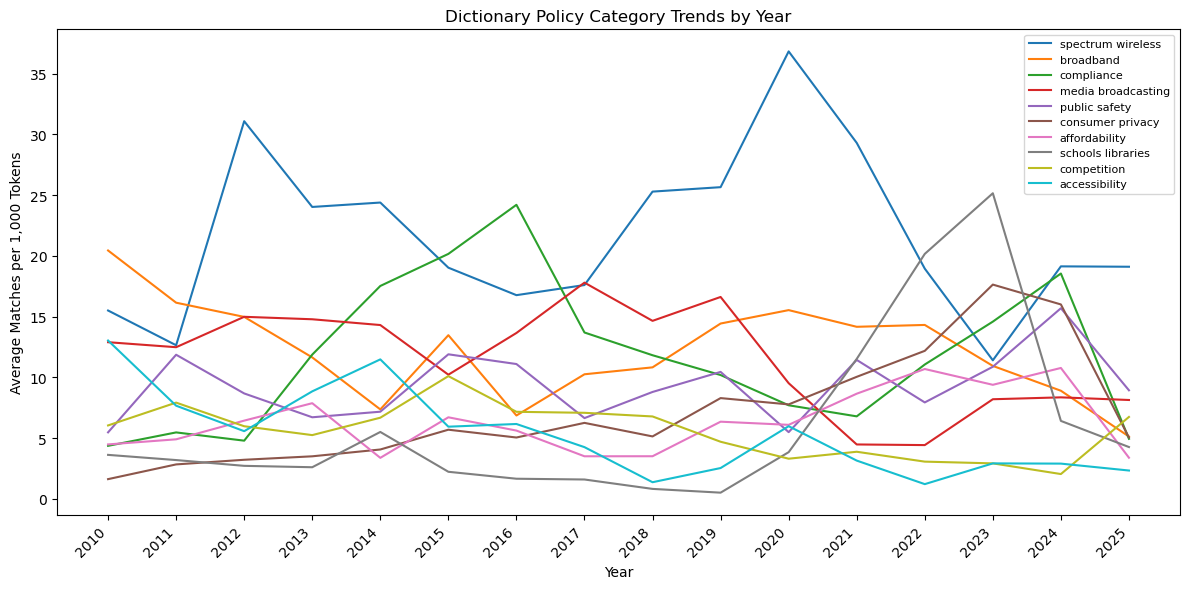

In [77]:
# Plot the top dictionary policy trends by year.
policy_trend_rate_cols = [f'{category}_avg_rate_per_1000_tokens' for category in policy_categories]

plot_lines(
    dictionary_policy_trend_by_year,
    'year',
    policy_trend_rate_cols,
    'Dictionary Policy Category Trends by Year',
    'Average Matches per 1,000 Tokens',
    'policy_category_trends_by_year.png',
    top_n=10
)

# 7. Topic Modeling: Baseline

## 7.1. Initial Settings

In [78]:
# Create a count vectorizer for topic modeling.
topic_count_vectorizer = CountVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    ngram_range=(1, 2),
    max_df=0.85,
    min_df=5,
    max_features=7000
)

# Create the document-term count matrix.
X_topic_count = topic_count_vectorizer.fit_transform(df['clean_text'].fillna(''))

# Get the vocabulary terms from the count vectorizer.
topic_terms = topic_count_vectorizer.get_feature_names_out()

In [79]:
# Create a TF-IDF vectorizer using the same vocabulary.
topic_tfidf_vectorizer = TfidfVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    vocabulary=topic_count_vectorizer.vocabulary_,
    use_idf=True,
    norm='l2'
)

# Create the document-term TF-IDF matrix.
X_topic_tfidf = topic_tfidf_vectorizer.fit_transform(df['clean_text'].fillna(''))

In [80]:
# Basic checks for the count and TF-IDF matrices.
topic_modeling_sanity_checks_dict = {
    'count_matrix_shape': str(X_topic_count.shape),
    'tfidf_matrix_shape': str(X_topic_tfidf.shape),
    'topic_vocabulary_size': len(topic_terms)
}

topic_modeling_sanity_checks = pd.DataFrame(
    topic_modeling_sanity_checks_dict.items(),
    columns=['metric', 'value']
)

save_table(topic_modeling_sanity_checks, 'topic_modeling_sanity_checks.csv')

topic_modeling_sanity_checks

,metric,value
0,count_matrix_shape,"(3073, 7000)"
1,tfidf_matrix_shape,"(3073, 7000)"
2,topic_vocabulary_size,7000


In [81]:
# Set the number of top words used for topic inspection and evaluation.
TOPIC_TOP_N_WORDS = 10

# Set the  minimum number of valid words per topic for coherence evaluation.
TOPIC_COHERENCE_MINIMUM_WORDS = 2

In [82]:
# Convert cleaned texts into token lists and remove empty lists.
topic_evaluation_tokenized_texts = (
    df['clean_text']
    .fillna('')
    .str.split()
    .tolist()
)

topic_evaluation_tokenized_texts = [
    tokens
    for tokens in topic_evaluation_tokenized_texts
    if len(tokens) > 0
]

# Create a Gensim dictionary from the tokenized texts.
topic_evaluation_dictionary = Dictionary(topic_evaluation_tokenized_texts)

# Convert tokenized texts into bag-of-words format.
topic_evaluation_corpus = [
    topic_evaluation_dictionary.doc2bow(tokens)
    for tokens in topic_evaluation_tokenized_texts
]

# Store coherence evaluation settings in a dataframe.
topic_coherence_evaluation_settings = pd.DataFrame([{
    'top_n_words': TOPIC_TOP_N_WORDS,
    'minimum_words_per_topic': TOPIC_COHERENCE_MINIMUM_WORDS,
    'n_texts_for_coherence': len(topic_evaluation_tokenized_texts),
    'coherence_dictionary_size': len(topic_evaluation_dictionary),
}])

save_table(topic_coherence_evaluation_settings, 'topic_coherence_evaluation_settings.csv')

topic_coherence_evaluation_settings

,top_n_words,minimum_words_per_topic,n_texts_for_coherence,coherence_dictionary_size
0,10,2,3073,9023


## 7.2. Define Helper Functions

In [83]:
def get_topic_words(model, terms, n_top_words=TOPIC_TOP_N_WORDS):
    rows = []

    # Loop through each topic and its word weights.
    for topic_idx, topic_weights in enumerate(model.components_):

        # Get indices of the top n words for this topic.
        top_indices = np.argsort(topic_weights)[::-1][:n_top_words]

        # Store each top word with its rank and weight.
        for rank, term_idx in enumerate(top_indices, start=1):
            rows.append({
                'topic': topic_idx,
                'rank': rank,
                'term': terms[term_idx],
                'weight': float(topic_weights[term_idx]),
            })

    # Convert the results into a dataframe.
    return pd.DataFrame(rows)

In [84]:
def extract_top_words_by_topic(
    topic_words_df,
    top_n=TOPIC_TOP_N_WORDS,
    topic_col='topic',
    rank_col='rank',
    term_col='term',
    exclude_outlier=True
):

    # Copy the topic-word table.
    words = topic_words_df.copy()

    # Remove outlier topic if requested.
    if exclude_outlier:
        
        topic_numeric = words[topic_col]
        words = words.loc[topic_numeric.ne(-1) | topic_numeric.isna()].copy()

    # Create empty dictionary to store top words by topic.
    topic_word_lists = {}

    # Process each topic separately.
    for topic, group in words.groupby(topic_col, sort=True):

        # Sort words by rank and clean term strings.
        terms = (
            group
            .sort_values(rank_col)[term_col]
            .dropna()
            .str.strip()
        )

        # Remove empty terms.
        terms = [term for term in terms if term]

        # Keep only the top n words for each topic.
        topic_word_lists[topic] = terms[:top_n]

    # Return topic-to-word-list dictionary.
    return topic_word_lists

In [85]:
def normalize_topic_scores(topic_matrix):

    # Calculate the total topic score for each document.
    row_sums = topic_matrix.sum(axis=1, keepdims=True)

    # Avoid division by zero for documents with no topic scores.
    row_sums[row_sums == 0] = 1

    # Convert topic scores into row-wise proportions.
    return topic_matrix / row_sums

In [86]:
def calculate_topic_diversity(topic_word_lists):

    # Flatten all topic-word lists into one list.
    top_words = [
        word
        for words in topic_word_lists.values()
        for word in words
    ]

    # Return NaN if there are no words to evaluate
    if len(top_words) == 0:
        return np.nan

    # Calculate the share of unique words among all top words.
    return len(set(top_words)) / len(top_words)

In [87]:
def valid_words_for_coherence(topic_words, dictionary):

    # Return no words if the dictionary is missing.
    if dictionary is None:
        return []

    # Create a fast lookup set of dictionary tokens.
    token_lookup = set(dictionary.token2id)

    # Create container of valid words
    valid_words = []
    seen_words = set()

    # Check each topic word.
    for term in topic_words:

        # Remove extra spaces.
        term = term.strip()

        # Skip empty terms.
        if not term:
            continue

        # Keep the full term if it exists in the dictionary.
        if term in token_lookup:
            candidate_words = [term]
        # Otherwise, split phrases into individual words.
        else:
            candidate_words = term.replace('_', ' ').split()

        # Check each candidate word.
        for candidate in candidate_words:

            # Remove extra spaces.
            candidate = candidate.strip()

            # Keep only valid and non-duplicate words.
            if candidate in token_lookup and candidate not in seen_words:
                valid_words.append(candidate)
                seen_words.add(candidate)

    # Return words that can be used for coherence.
    return valid_words

In [88]:
def calculate_topic_coherence(
    topic_word_lists,
    tokenized_texts,
    dictionary,
    corpus=None,
    coherence='c_v',
    minimum_words=TOPIC_COHERENCE_MINIMUM_WORDS
):

    # Return NaN if required coherence inputs are missing.
    if dictionary is None or len(tokenized_texts) == 0:
        return np.nan

    # Create container to store topics with enough valid words.
    valid_topics = []

    # Validate topic words against the dictionary.
    for topic_words in topic_word_lists.values():
        
        valid_words = valid_words_for_coherence(topic_words, dictionary)

        # Keep only topics with enough valid words.
        if len(valid_words) >= minimum_words:
            valid_topics.append(valid_words)

    # Return NaN if no topics can be evaluated.
    if len(valid_topics) == 0:
        return np.nan
    
    try:
        # Use corpus-based coherence for u_mass.
        if coherence == 'u_mass':

            # Create a corpus if one was not provided.
            if corpus is None:
                corpus = [dictionary.doc2bow(tokens) for tokens in tokenized_texts]

            # Build the coherence model using the corpus.
            coherence_model = CoherenceModel(
                topics=valid_topics,
                corpus=corpus,
                dictionary=dictionary,
                coherence=coherence,
                processes=1
            )

        # Use text-based coherence for c_v and other metrics.
        else:
            # Build the coherence model using tokenized texts.
            coherence_model = CoherenceModel(
                topics=valid_topics,
                texts=tokenized_texts,
                dictionary=dictionary,
                coherence=coherence,
                processes=1
            )

        # Calculate and return the coherence score.
        return float(coherence_model.get_coherence())

    # Return NaN if coherence calculation fails.
    except Exception:
        return np.nan

In [89]:
def topic_redundancy(topic_words_df, top_n=TOPIC_TOP_N_WORDS):

    # Create one set of top words for each topic.
    topic_sets = [
        set(group['term'])
        for _, group in topic_words_df[topic_words_df['rank'] <= top_n].groupby('topic')
    ]

    # Return zero redundancy if fewer than two topics exist.
    if len(topic_sets) < 2:
        return 0.0, 0

    # Create container to store pairwise topic similarities.
    similarities = []
    # Set to zero to count topic pairs with high overlap.
    high_redundancy_pairs = 0

    # Compare every pair of topics once.
    for i in range(len(topic_sets)):
        for j in range(i + 1, len(topic_sets)):

            # Count all unique words across the two topics.
            union_size = len(topic_sets[i] | topic_sets[j])
            # Calculate similarity between the two topics.
            similarity = len(topic_sets[i] & topic_sets[j]) / union_size if union_size else 0
            # Store the similarity score.
            similarities.append(similarity)

            # Count highly redundant topic pairs.
            if similarity >= 0.5:
                high_redundancy_pairs += 1

    # Return average redundancy and number of highly redundant pairs.
    return float(np.mean(similarities)), high_redundancy_pairs

In [90]:
def dictionary_topic_alignment(dataframe, policy_rate_cols, topic_cols):

    # Calculate correlations between policy-rate columns and topic columns.
    correlation = dataframe[policy_rate_cols + topic_cols].corr().loc[policy_rate_cols, topic_cols]

    # Return the average of strongest topic alignment for each policy category.
    return correlation.max(axis=1).mean()

In [91]:
def evaluate_nmf_topic_count(policy_rate_cols, n_topics):

    # Create an NMF model with the selected number of topics.
    model = NMF(
        n_components=n_topics, 
        init='nndsvda', 
        random_state=RANDOM_STATE, 
        max_iter=400
    )

    # Fit the model and get document-topic scores.
    doc_topic = model.fit_transform(X_topic_tfidf)

    # Normalize topic scores within each document.
    doc_topic_normalized = normalize_topic_scores(doc_topic)

    # Create column names for topic scores.
    topic_cols = [f'topic_{idx}' for idx in range(n_topics)]

    # Combine policy-rate columns and topic-score columns.
    temp_df = pd.concat(
        [df[policy_rate_cols].reset_index(drop=True), 
         pd.DataFrame(doc_topic_normalized, columns=topic_cols)],
        axis=1,
    )

    # Extract top words for each topic.
    topic_words = get_topic_words(model, topic_terms, n_top_words=TOPIC_TOP_N_WORDS)

    # Convert topic words into topic-to-word lists.
    topic_word_lists = extract_top_words_by_topic(
        topic_words,
        top_n=TOPIC_TOP_N_WORDS
    )

    # Calculate topic diversity.
    topic_diversity = calculate_topic_diversity(topic_word_lists)

    # Calculate topic coherence.
    coherence_score = calculate_topic_coherence(
        topic_word_lists,
        topic_evaluation_tokenized_texts,
        topic_evaluation_dictionary,
        corpus=topic_evaluation_corpus,
        coherence='c_v',
        minimum_words=TOPIC_COHERENCE_MINIMUM_WORDS
    )

    # Calculate average topic prevalence.
    prevalence = doc_topic_normalized.mean(axis=0)

    # Calculate topic redundancy.
    redundancy_mean, high_redundancy_pairs = topic_redundancy(topic_words)

    # Calculate alignment between dictionary categories and topics.
    policy_topic_alignment = dictionary_topic_alignment(temp_df, policy_rate_cols, topic_cols)
    
    return {
        'model': 'NMF',
        'n_topics': n_topics,
        f'topic_diversity_top{TOPIC_TOP_N_WORDS}': topic_diversity,
        f'coherence_c_v_top{TOPIC_TOP_N_WORDS}': coherence_score,
        'avg_max_document_topic_probability': doc_topic_normalized.max(axis=1).mean(),
        'min_topic_prevalence': prevalence.min(),
        'max_topic_prevalence': prevalence.max(),
        'low_prevalence_topics': int((prevalence < 0.01).sum()),
        'topic_redundancy_mean': redundancy_mean,
        'high_redundancy_topic_pairs': high_redundancy_pairs,        
        'reconstruction_error': model.reconstruction_err_,
        'avg_best_policy_topic_alignment': policy_topic_alignment,
    }, topic_words.assign(n_topics=n_topics)

In [92]:
def evaluate_lda_topic_count(policy_rate_cols, n_topics):

    # Create an LDA model with the selected number of topics.
    model = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=RANDOM_STATE,
        learning_method='batch',
        max_iter=15,
        n_jobs=-1,
    )

    # Fit the model and get document-topic probabilities.
    doc_topic = model.fit_transform(X_topic_count)

    # Create column names for topic scores.
    topic_cols = [f'topic_{idx}' for idx in range(n_topics)]

    # Combine policy-rate columns and topic-score columns.
    temp_df = pd.concat(
        [df[policy_rate_cols].reset_index(drop=True), 
         pd.DataFrame(doc_topic, columns=topic_cols)],
        axis=1,
    )

    # Extract top words for each topic.
    topic_words = get_topic_words(model, topic_terms, n_top_words=TOPIC_TOP_N_WORDS)

    # Convert topic words into topic-to-word lists.
    topic_word_lists = extract_top_words_by_topic(
        topic_words,
        top_n=TOPIC_TOP_N_WORDS
    )

    # Calculate topic diversity.
    topic_diversity = calculate_topic_diversity(topic_word_lists)

    # Calculate topic coherence.
    coherence_score = calculate_topic_coherence(
        topic_word_lists,
        topic_evaluation_tokenized_texts,
        topic_evaluation_dictionary,
        corpus=topic_evaluation_corpus,
        coherence='c_v',
        minimum_words=TOPIC_COHERENCE_MINIMUM_WORDS
    )

    # Calculate average topic prevalence.
    prevalence = doc_topic.mean(axis=0)

    # Calculate topic redundancy.
    redundancy_mean, high_redundancy_pairs = topic_redundancy(topic_words)

    # Calculate alignment between dictionary categories and topics.
    policy_topic_alignment = dictionary_topic_alignment(temp_df, policy_rate_cols, topic_cols)

    return {
        'model': 'LDA',
        'n_topics': n_topics,
        f'topic_diversity_top{TOPIC_TOP_N_WORDS}': topic_diversity,
        f'coherence_c_v_top{TOPIC_TOP_N_WORDS}': coherence_score,
        'avg_max_document_topic_probability': doc_topic.max(axis=1).mean(),
        'min_topic_prevalence': prevalence.min(),
        'max_topic_prevalence': prevalence.max(),
        'low_prevalence_topics': int((prevalence < 0.01).sum()),
        'topic_redundancy_mean': redundancy_mean,
        'high_redundancy_topic_pairs': high_redundancy_pairs,
        'perplexity': model.perplexity(X_topic_count),
        'log_likelihood': model.score(X_topic_count),
        'avg_best_policy_topic_alignment': policy_topic_alignment,
    }, topic_words.assign(n_topics=n_topics)

In [93]:
def topic_trend_by_period(dataframe, topic_cols, period_col):

    # Calculate average topic scores by period.
    trend = dataframe.groupby(period_col, sort=True)[topic_cols].mean().reset_index()

    # Count the number of documents by period.
    document_counts = dataframe.groupby(period_col, sort=True).size().rename('n_documents').reset_index()

    # Combine document counts with average topic scores.
    return document_counts.merge(trend, on=period_col, how='left')

In [94]:
def representative_documents(dataframe, topic_cols, model_name, n_documents=5):

    # Create container to store representative document rows.
    rows = []

    # Process each topic column.
    for topic_col in topic_cols:

        # Extract the topic ID from the column name.
        topic_id = int(topic_col.split('_')[-1])

        # Select documents with the highest topic probabilities.
        top_documents = dataframe.sort_values(topic_col, ascending=False).head(n_documents)

        # Store the top documents for the topic.
        for rank, (_, row) in enumerate(top_documents.iterrows(), start=1):
            
            rows.append({
                'model': model_name,
                'topic': topic_id,
                'rank': rank,
                'topic_probability': row[topic_col],
                'filename': row['filename'],
                'title': row['page_title'],
                'year': row['year'],
                'dominant_policy_category': row['dominant_policy_category'],
                'dominant_policy_category_score': row['dominant_policy_category_score'],
                'matched_dictionary_terms': row['all_policy_matched_terms'],
                'text_preview': str(row.get('body_text', ''))[:700].replace('\n', ' '),
            })

    # Convert the rows into a dataframe.
    return pd.DataFrame(rows)

## 7.3. (1) NMF Topic Modeling

### 7.3.1. Evaluate Number of Topics

In [95]:
# Define candidate topic numbers to evaluate.
candidate_topic_counts = [5, 8, 10, 12, 15, 18, 20, 25]

# Create container to store NMF evaluation results and topic words for each candidate model.
nmf_evaluation_rows = []
nmf_candidate_topic_words = []

# Evaluate NMF models with different topic counts.
for n_topics in tqdm(candidate_topic_counts):
    evaluation_row, topic_words = evaluate_nmf_topic_count(policy_rate_cols, n_topics)
    nmf_evaluation_rows.append(evaluation_row)
    nmf_candidate_topic_words.append(topic_words)

# Convert evaluation results and topic-word tables into a dataframe and save them.
nmf_topic_number_evaluation = pd.DataFrame(nmf_evaluation_rows)
nmf_candidate_topic_words = pd.concat(nmf_candidate_topic_words, ignore_index=True)

save_table(nmf_topic_number_evaluation, 'nmf_topic_number_evaluation.csv')
save_table(nmf_candidate_topic_words, 'nmf_candidate_topic_words.csv')

  0%|          | 0/8 [00:00<?, ?it/s]

In [96]:
nmf_topic_number_evaluation

,model,n_topics,topic_diversity_top10,coherence_c_v_top10,avg_max_document_topic_probability,min_topic_prevalence,max_topic_prevalence,low_prevalence_topics,topic_redundancy_mean,high_redundancy_topic_pairs,reconstruction_error,avg_best_policy_topic_alignment
0,NMF,5,0.980000,0.684881,0.655979,0.108401,0.296206,0,0.005263,0,51.995424,0.332876
1,NMF,8,0.950000,0.741589,0.632351,0.068988,0.263758,0,0.007519,0,51.027256,0.473062
2,NMF,10,0.920000,0.735609,0.606394,0.059634,0.166199,0,0.010656,0,50.515230,0.541077
3,NMF,12,0.916667,0.732114,0.593739,0.049992,0.125957,0,0.008861,0,50.082477,0.591683
4,NMF,15,0.913333,0.748117,0.584736,0.042331,0.149505,0,0.007686,0,49.441230,0.658823
5,NMF,18,0.911111,0.750883,0.560864,0.026868,0.109092,0,0.007384,0,48.959753,0.704047
6,NMF,20,0.905000,0.729300,0.542643,0.026240,0.083494,0,0.007295,0,48.657538,0.738556
7,NMF,25,0.864000,0.725835,0.531326,0.019313,0.087075,0,0.007723,0,48.012939,0.739124


In [97]:
nmf_candidate_topic_words

,topic,rank,term,weight,n_topics
0,0,1,spectrum,1.137020,5
1,0,2,auction,1.031016,5
2,0,3,broadband,0.802525,5
3,0,4,rural,0.656808,5
4,0,5,band,0.621492,5
...,...,...,...,...,...
1125,24,6,competition,0.321776,25
1126,24,7,speed,0.307698,25
1127,24,8,carrier,0.301507,25
1128,24,9,requirement,0.292534,25


### 7.3.2. Analysis Results

In [98]:
# Set the final number of NMF topics.
NMF_TOPIC_COUNT = 18

# Create the final NMF model.
nmf_model = NMF(
    n_components=NMF_TOPIC_COUNT, 
    init='nndsvda', 
    random_state=RANDOM_STATE, 
    max_iter=500
)

In [99]:
# Fit the model and get raw document-topic scores.
nmf_doc_topic_raw = nmf_model.fit_transform(X_topic_tfidf)

# Normalize document-topic scores.
nmf_doc_topic = normalize_topic_scores(nmf_doc_topic_raw)

# Create NMF topic-score column names.
nmf_topic_cols = [f'nmf_topic_{idx}' for idx in range(NMF_TOPIC_COUNT)]

# Add NMF topic scores to the main dataframe.
for idx, col in enumerate(nmf_topic_cols):
    df[col] = nmf_doc_topic[:, idx]

In [100]:
# Assign the dominant NMF topic and topic score for each document.
df['dominant_nmf_topic'] = np.argmax(nmf_doc_topic, axis=1)

df['dominant_nmf_topic_score'] = np.max(nmf_doc_topic, axis=1)

In [101]:
# Extract top words and representative documents for each final NMF topic.
nmf_topic_words = get_topic_words(nmf_model, topic_terms, n_top_words=TOPIC_TOP_N_WORDS)

REPRESENTATIVE_DOCUMENTS = 5
nmf_representative_documents = representative_documents(df, nmf_topic_cols, 'NMF', n_documents=REPRESENTATIVE_DOCUMENTS)

save_table(nmf_topic_words, 'nmf_topic_words.csv')
save_table(nmf_representative_documents, 'nmf_representative_documents.csv')

In [102]:
nmf_topic_words

,topic,rank,term,weight
0,0,1,broadband,2.678965
1,0,2,rural,1.869503
2,0,3,speed,1.030740
3,0,4,caf,0.972116
4,0,5,area,0.913984
...,...,...,...,...
175,17,6,ip_cts,0.325489
176,17,7,rate,0.312475
177,17,8,hearing,0.298624
178,17,9,user,0.297905


In [103]:
nmf_representative_documents

,model,topic,rank,topic_probability,filename,title,year,dominant_policy_category,dominant_policy_category_score,matched_dictionary_terms,text_preview
0,NMF,0,1,0.994194,150827_CenturyLink_Accepts_$506_M_from_Connect...,CenturyLink Accepts $506 M from Connect Americ...,2015,broadband,93.750000,affordability: caf (6); universal service (2);...,"CenturyLink, Inc. has accepted $505,703,762 in..."
1,NMF,0,2,0.984668,150827_Cincinnati_Bell_Accepts_$2.2_M_for_Rura...,Cincinnati Bell Accepts $2.2 M for Rural Broad...,2015,broadband,97.560976,affordability: caf (7); universal service (2);...,"Cincinnati Bell has accepted $2,229,130 in ann..."
2,NMF,0,3,0.979143,150827_ATT_Accepts_$428_M_From_Connect_America...,AT&T Accepts $428 M From Connect America Fund ...,2015,broadband,88.757396,affordability: caf (6); universal service (2);...,"AT&T, Inc. has accepted $427,706,650 in annual..."
3,NMF,0,4,0.974994,150616_Connect_America_Fund_Expanding_Broadban...,Connect America Fund Expanding Broadband to 1....,2015,broadband,105.960265,affordability: caf (5); universal service (2);...,"D.C. (June 16, 2015) Frontier Communications I..."
4,NMF,0,5,0.969086,150827_Consolidated_Accepts_$14_M_From_Connect...,Consolidated Accepts $14 M From Connect Americ...,2015,broadband,98.684211,affordability: caf (7); universal service (2);...,"Consolidated Telecom, Inc. has accepted $13,92..."
...,...,...,...,...,...,...,...,...,...,...,...
85,NMF,17,1,1.000000,200930_FCC_Reforms_IP_Captioned_Telephone_Serv...,FCC Reforms IP Captioned Telephone Service Rates,2020,accessibility,148.148148,accessibility: trs (11); ip_cts (8); captionin...,The FCC today took action to ensure that high-...
86,NMF,17,2,1.000000,230928_FCC_Increases_Video_Relay_Service_Suppo...,FCC Increases Video Relay Service Support & Up...,2023,accessibility,121.212121,accessibility: vrs (13); trs (3); asl (3); dis...,The Federal Communications Commission on Septe...
87,NMF,17,3,1.000000,110406_TRS_FUND_ADMINISTRATOR_NAMED.txt,TRS FUND ADMINISTRATOR NAMED,2011,accessibility,140.243902,accessibility: trs (20); disability (2); cvaa ...,The Commission has awarded Rolka Loube Saltzer...
88,NMF,17,4,0.996342,210520_FCC_Seeks_Comment_on_Compensation_Plan_...,FCC Seeks Comment on Compensation Plan for Vid...,2021,accessibility,99.236641,accessibility: vrs (10); trs (3),The FCC took action today in its role overseei...


### 7.3.3. Trends by Year, Quarter and Month

In [104]:
# Calculate NMF topic trends by year, quarter and month.
nmf_topic_trend_by_year = topic_trend_by_period(df, nmf_topic_cols, 'year')
nmf_topic_trend_by_quarter = topic_trend_by_period(df, nmf_topic_cols, 'quarter')
nmf_topic_trend_by_month = topic_trend_by_period(df, nmf_topic_cols, 'month')

save_table(nmf_topic_trend_by_year, 'nmf_topic_trend_by_year.csv')
save_table(nmf_topic_trend_by_quarter, 'nmf_topic_trend_by_quarter.csv')
save_table(nmf_topic_trend_by_month, 'nmf_topic_trend_by_month.csv')

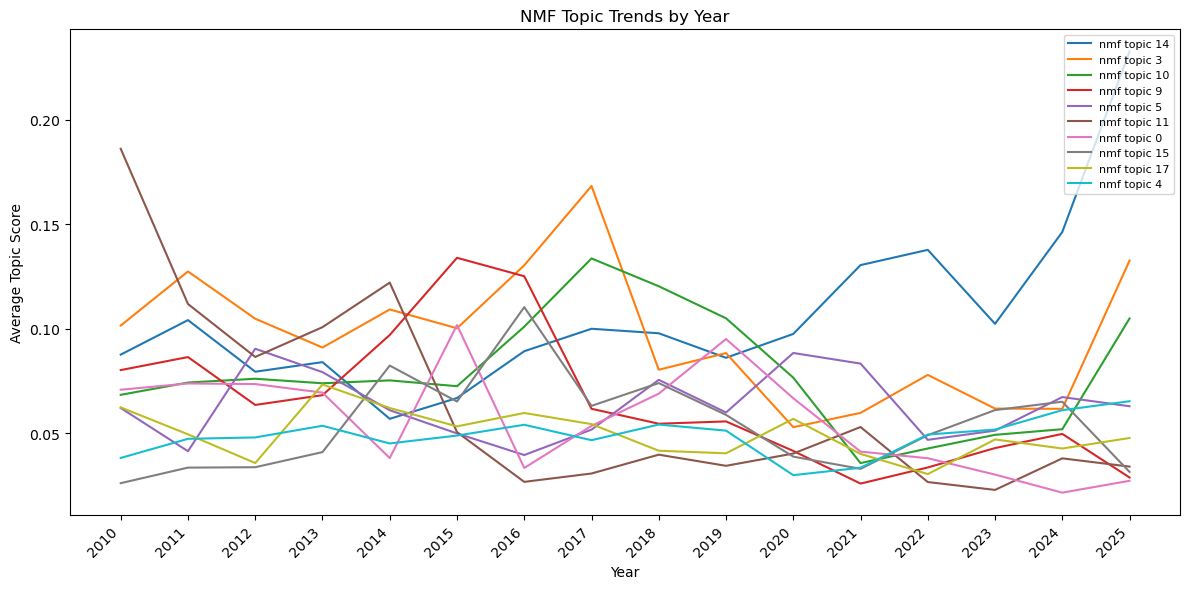

In [105]:
# Plot the top NMF topic trends by year.
plot_lines(
    nmf_topic_trend_by_year, 
    'year', 
    nmf_topic_cols, 
    'NMF Topic Trends by Year', 
    'Average Topic Score',
    'nmp_topic_trends_by_year',
    top_n=10
)

## 7.4. (2) LDA Topic Modeling

### 7.4.1. Evaluate Number of Topics

In [106]:
# Create container to store LDA evaluation results and topic words for each candidate model.
lda_evaluation_rows = []
lda_candidate_topic_words = []

# Evaluate LDA models with different topic counts.
for n_topics in tqdm(candidate_topic_counts):
    evaluation_row, topic_words = evaluate_lda_topic_count(policy_rate_cols, n_topics)
    lda_evaluation_rows.append(evaluation_row)
    lda_candidate_topic_words.append(topic_words)

# Convert evaluation results and topic-word tables into a dataframe and save them.
lda_topic_number_evaluation = pd.DataFrame(lda_evaluation_rows)
lda_candidate_topic_words = pd.concat(lda_candidate_topic_words, ignore_index=True)

save_table(lda_topic_number_evaluation, 'lda_topic_number_evaluation.csv')
save_table(lda_candidate_topic_words, 'lda_candidate_topic_words.csv')

  0%|          | 0/8 [00:00<?, ?it/s]

In [107]:
lda_topic_number_evaluation

,model,n_topics,topic_diversity_top10,coherence_c_v_top10,avg_max_document_topic_probability,min_topic_prevalence,max_topic_prevalence,low_prevalence_topics,topic_redundancy_mean,high_redundancy_topic_pairs,perplexity,log_likelihood,avg_best_policy_topic_alignment
0,LDA,5,0.880000,0.520059,0.754389,0.088941,0.259300,0,0.048538,0,1588.351798,-4.537803e+06,0.374776
1,LDA,8,0.800000,0.576331,0.676083,0.047239,0.205631,0,0.039511,0,1476.307138,-4.492765e+06,0.445415
2,LDA,10,0.800000,0.569864,0.658229,0.031976,0.196323,0,0.039497,0,1361.810516,-4.443062e+06,0.489860
3,LDA,12,0.766667,0.561705,0.669963,0.021171,0.179307,0,0.040429,0,1293.997290,-4.411614e+06,0.541777
4,LDA,15,0.800000,0.554755,0.662050,0.020050,0.142965,0,0.027008,0,1223.950885,-4.377350e+06,0.561505
5,LDA,18,0.761111,0.590717,0.647503,0.019854,0.138106,0,0.032618,0,1187.210835,-4.358586e+06,0.585398
6,LDA,20,0.765000,0.596297,0.641309,0.019205,0.127794,0,0.028640,0,1166.188822,-4.347587e+06,0.590656
7,LDA,25,0.696000,0.604034,0.620110,0.014352,0.101739,0,0.030640,0,1113.676603,-4.319220e+06,0.638886


In [108]:
lda_candidate_topic_words

,topic,rank,term,weight,n_topics
0,0,1,service,1719.109040,5
1,0,2,provide,1072.153490,5
2,0,3,station,997.497499,5
3,0,4,public,912.112778,5
4,0,5,support,822.229572,5
...,...,...,...,...,...
1125,24,6,provider,404.512833,25
1126,24,7,income,367.293127,25
1127,24,8,low,335.146535,25
1128,24,9,eligible,315.647315,25


### 7.4.2. Analysis Results

In [109]:
# Set the final number of LDA topics.
LDA_TOPIC_COUNT = 20

# Create the final LDA model.
lda_model = LatentDirichletAllocation(
    n_components=LDA_TOPIC_COUNT,
    random_state=RANDOM_STATE,
    learning_method='batch',
    max_iter=25,
    n_jobs=-1,
)

In [110]:
# Fit the model and get document-topic probabilities.
lda_doc_topic = lda_model.fit_transform(X_topic_count)

# Create LDA topic-probabilities column names.
lda_topic_cols = [f'lda_topic_{idx}' for idx in range(LDA_TOPIC_COUNT)]

# Add LDA topic probabilities to the main dataframe.
for idx, col in enumerate(lda_topic_cols):
    df[col] = lda_doc_topic[:, idx]

In [111]:
# Assign the dominant LDA topic and topic probability for each document.
df['dominant_lda_topic'] = np.argmax(lda_doc_topic, axis=1)

df['dominant_lda_topic_probability'] = np.max(lda_doc_topic, axis=1)

In [112]:
# Extract top words and representative documents for each final LDA topic.
lda_topic_words = get_topic_words(lda_model, topic_terms, n_top_words=TOPIC_TOP_N_WORDS)
lda_representative_documents = representative_documents(df, lda_topic_cols, 'LDA', n_documents=REPRESENTATIVE_DOCUMENTS)

save_table(lda_topic_words, 'lda_topic_words.csv')
save_table(lda_representative_documents, 'lda_representative_documents.csv')

In [113]:
lda_topic_words

,topic,rank,term,weight
0,0,1,service,550.703231
1,0,2,security,506.006060
2,0,3,trs,393.798611
3,0,4,video,358.838010
4,0,5,programming,331.519079
...,...,...,...,...
195,19,6,provider,368.749348
196,19,7,broadband,361.903249
197,19,8,ensure,353.698437
198,19,9,new,308.880383


In [114]:
lda_representative_documents

,model,topic,rank,topic_probability,filename,title,year,dominant_policy_category,dominant_policy_category_score,matched_dictionary_terms,text_preview
0,LDA,0,1,0.994751,240926_FCC_Adopts_Rules_to_Improve_Access_to_V...,FCC Adopts Rules to Improve Access to Video Co...,2024,accessibility,132.867133,accessibility: accessibility (5); people disab...,The Federal Communications Commission today ad...
1,LDA,0,2,0.993310,201210_FCC_Affirms_Designation_of_Huawei_as_Na...,FCC Affirms Designation of Huawei as National ...,2020,national_security,115.044248,affordability: usf (2) | national_security: hu...,The Federal Communications Commission today to...
2,LDA,0,3,0.992149,201118_FCC_Proposes_More_Equitable_Funding_Str...,FCC Proposes More Equitable Funding Structure ...,2020,accessibility,142.857143,accessibility: trs (6); ip_relay (3); vrs (3);...,The FCC today approved a Notice of Proposed Ru...
3,LDA,0,4,0.989785,130327_Live_and_Near-Live_Internet_Captioning_...,Live and Near-Live Internet Captioning Rules G...,2013,media_broadcasting,86.419753,accessibility: closed_captioning (3); cvaa (2)...,Rules requiring closed captions on live and ne...
4,LDA,0,5,0.976862,210217_FCC_Seeks_Comment_on_Modifying_Supply_C...,FCC Seeks Comment on Modifying Supply Chain Rules,2021,national_security,78.431373,national_security: national security threat (2...,The Federal Communications Commission today vo...
...,...,...,...,...,...,...,...,...,...,...,...
95,LDA,19,1,0.991518,170518_FCC_Proposes_Ending_Utility-Style_Regul...,FCC Proposes Ending Utility-Style Regulation o...,2017,broadband,30.927835,broadband: broadband_internet (2); internet se...,The Federal Communications Commission today to...
96,LDA,19,2,0.984227,"160804_FCC_Adopts_Sustainable,_Affordable_Inma...","FCC Adopts Sustainable, Affordable Inmate Call...",2016,affordability,6.493506,affordability: high cost,The Federal Communications Commission today to...
97,LDA,19,3,0.974324,120806_Chairman_Genachowski_Statement_on_the_1...,Chairman Genachowski Statement on the 10th Cir...,2012,competition,85.714286,competition: competition (2); forbearance,This is another important legal victory for th...
98,LDA,19,4,0.952500,100108_FCC_CHAIRMAN_GENACHOWSKI_STATEMENT_ON_D...,FCC CHAIRMAN GENACHOWSKI STATEMENT ON D.C. CIR...,2010,competition,58.823529,competition: open_internet,"""This case underscores the importance of the F..."


### 7.4.3. Trends by Year, Quarter and Month

In [115]:
# Calculate LDA topic trends by year, quarter and month.
lda_topic_trend_by_year = topic_trend_by_period(df, lda_topic_cols, 'year')
lda_topic_trend_by_quarter = topic_trend_by_period(df, lda_topic_cols, 'quarter')
lda_topic_trend_by_month = topic_trend_by_period(df, lda_topic_cols, 'month')

save_table(lda_topic_trend_by_year, 'lda_topic_trend_by_year.csv')
save_table(lda_topic_trend_by_quarter, 'lda_topic_trend_by_quarter.csv')
save_table(lda_topic_trend_by_month, 'lda_topic_trend_by_month.csv')

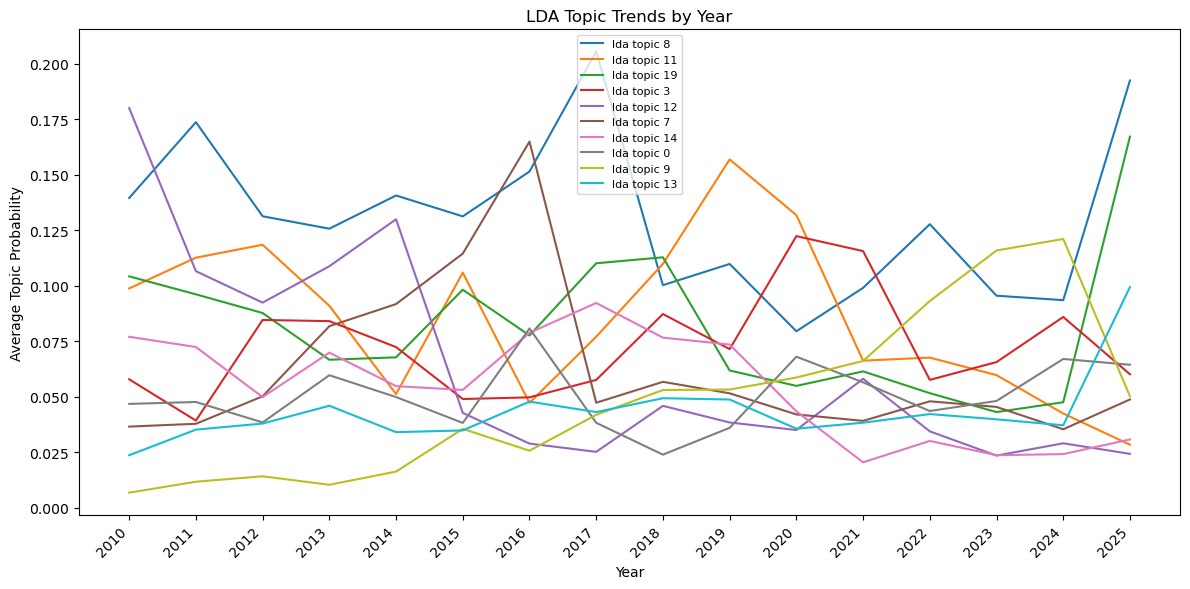

In [116]:
# Plot the top LDA topic trends by year.
plot_lines(
    lda_topic_trend_by_year, 
    'year', 
    lda_topic_cols, 
    'LDA Topic Trends by Year', 
    'Average Topic Probability',
    'lda_topic_trends_by_year.png',
    top_n=10
)

# 8. Topic Modeling: BERTopic

## 8.1. Prepare Text for BERTopic

In [117]:
# Select the text column for BERTopic.
BERTOPIC_TEXT_COL = 'body_text'

# Set the minimum number of tokens required for BERTopic input.
BERTOPIC_MIN_TOKEN_COUNT = 20

In [118]:
# Clean the selected text column.
bertopic_text = df[BERTOPIC_TEXT_COL].fillna('').astype(str).str.strip()

# Count words in each document
bertopic_token_counts = bertopic_text.str.split().map(len)

# Keep only non-empty documents with at least the minimum token count.
bertopic_valid_mask = bertopic_text.ne('') & bertopic_token_counts.ge(BERTOPIC_MIN_TOKEN_COUNT)

In [119]:
# Convert valid documents into a list for BERTopic.
bertopic_docs = bertopic_text.loc[bertopic_valid_mask].tolist()

# Store the original dataframe index of documents used in BERTopic.
bertopic_doc_index = df.index[bertopic_valid_mask]

# Store token counts only for documents used in BERTopic.
bertopic_doc_token_counts = bertopic_token_counts.loc[bertopic_valid_mask]

In [120]:
# Create a summary of the BERTopic input data.
bertopic_input_summary = pd.DataFrame([{
    'total_documents': int(len(df)),
    'documents_used_for_bertopic': int(bertopic_valid_mask.sum()),
    'minimum_token_threshold': BERTOPIC_MIN_TOKEN_COUNT,
    'selected_text_column': BERTOPIC_TEXT_COL,
    'min_word_count_included': int(bertopic_doc_token_counts.min()),
    'median_word_count_included': float(bertopic_doc_token_counts.median()),
    'max_word_count_included': int(bertopic_doc_token_counts.max()),
}])

save_table(bertopic_input_summary, 'bertopic_input_summary.csv')

bertopic_input_summary

,total_documents,documents_used_for_bertopic,minimum_token_threshold,selected_text_column,min_word_count_included,median_word_count_included,max_word_count_included
0,3073,3073,20,body_text,25,350.0,8115


## 8.2. Initial Settings

In [121]:
# Load the selected SentenceTransformer model.
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [122]:
# Create a BERTopic model with a chosen minimum topic size.
def make_bertopic_model(min_topic_size, verbose=False):

    return BERTopic(
        # Use the loaded embedding model.
        embedding_model=embedding_model,

        # Reduce embedding dimensions before clustering.
        umap_model=UMAP(
            n_neighbors=15,
            n_components=5,
            min_dist=0.0,
            metric='cosine',
            random_state=RANDOM_STATE
        ),

        # Cluster documents into topics.
        hdbscan_model=HDBSCAN(
            min_cluster_size=min_topic_size,
            min_samples=5,
            metric='euclidean',
            prediction_data=True
        ),

        # Extract topic words using custom tokenization.
        vectorizer_model=CountVectorizer(
            tokenizer=document_to_tokens,
            token_pattern=None,
            ngram_range=(1, 2),
            min_df=5,
            max_df=0.85
        ),

        # Set the number of top words per topic.
        top_n_words=TOPIC_TOP_N_WORDS,

        # Calculate document-topic probabilities.
        calculate_probabilities=True,

        # Control progress messages.
        verbose=verbose
    )


In [123]:
# Create embeddings for valid BERTopic documents.
bertopic_embeddings = embedding_model.encode(
    bertopic_docs,
    show_progress_bar=True
)

Batches:   0%|          | 0/97 [00:00<?, ?it/s]

## 8.3. Define Helper Functions

In [124]:
def extract_bertopic_document_probabilities(probabilities, topics):

    # Get the highest topic probability for each document.
    document_probabilities = np.nanmax(np.asarray(probabilities), axis=1)

    # Replace probabilities for outlier documents with NaN.
    return (
        pd.Series(document_probabilities)
        .where(pd.Series(topics).ne(-1), np.nan)
        .to_numpy()
    )

In [125]:
def get_bertopic_topic_words(topic_model, topic_ids, n_top_words=TOPIC_TOP_N_WORDS):

    # Create container to store topic-word rows.
    rows = []

    # Loop through each selected topic.
    for topic_id in topic_ids:

        # Get topic words, or use an empty list if none exist.
        topic_words = topic_model.get_topic(topic_id) or []

        # Keep only the top words.
        topic_words = topic_words[:n_top_words]

        # Add each topic word with its rank and weight.
        for rank, (term, weight) in enumerate(topic_words, start=1):

            rows.append({
                'topic': topic_id,
                'rank': rank,
                'term': term,
                'weight': float(weight),
            })

    # Return the result as a DataFrame.
    return pd.DataFrame(rows, columns=['topic', 'rank', 'term', 'weight'])

In [126]:
def evaluate_bertopic_min_topic_size(min_topic_size):

    # Create a BERTopic model with the selected minimum topic size.
    model = make_bertopic_model(min_topic_size)

    # Fit BERTopic using precomputed document embeddings.
    candidate_topics, candidate_probabilities = model.fit_transform(
        bertopic_docs,
        embeddings=bertopic_embeddings
    )

    # Get the topic summary table.
    topic_info = model.get_topic_info().copy()

    # Extract valid topic IDs, excluding the outlier topic.
    topic_ids = sorted(topic_info.loc[topic_info['Topic'].ne(-1), 'Topic'].astype(int))

    # Extract top words for each valid topic.
    topic_words = get_bertopic_topic_words(model, topic_ids)

    # Convert topic words into topic-to-word lists.
    topic_word_lists = extract_top_words_by_topic(
        topic_words, 
        top_n=TOPIC_TOP_N_WORDS
    )

    # Calculate topic diversity.
    topic_diversity = calculate_topic_diversity(topic_word_lists)

    # Calculate topic coherence.
    coherence_score = calculate_topic_coherence(
        topic_word_lists,
        topic_evaluation_tokenized_texts,
        topic_evaluation_dictionary,
        corpus=topic_evaluation_corpus,
        coherence='c_v',
        minimum_words=TOPIC_COHERENCE_MINIMUM_WORDS
    )

    # Calculate topic redundancy.
    redundancy_mean, high_redundancy_pairs = topic_redundancy(
        topic_words,
        top_n=TOPIC_TOP_N_WORDS
    )

    # Store assigned topic IDs as a pandas Series.
    assigned_topics = pd.Series(candidate_topics)

    # Count documents assigned to each non-outlier topic.
    non_outlier_topic_counts = assigned_topics.loc[assigned_topics.ne(-1)].value_counts().sort_index()

    # Calculate topic shares among all BERTopic input documents.
    non_outlier_topic_shares = non_outlier_topic_counts / len(assigned_topics)

    # Extract each document's strongest topic probability.
    document_probabilities = pd.Series(
        extract_bertopic_document_probabilities(candidate_probabilities, candidate_topics)
    )

    # Prepare policy dictionary scores for the same documents used by BERTopic.
    candidate_alignment_df = df.loc[bertopic_doc_index, policy_rate_cols].reset_index(drop=True).copy()

    # Convert BERTopic probabilities to a NumPy array.
    candidate_prob_matrix = np.asarray(candidate_probabilities)
    
    # Check that BERTopic returned topic probabilities for all topics.
    if candidate_prob_matrix.ndim != 2:
        raise ValueError(
            'BERTopic probabilities are not a 2D topic-probability matrix.'
        )
    
    # Create topic probability column names.
    candidate_topic_prob_cols = [f'topic_{topic_id}' for topic_id in topic_ids]
    
    # Add one probability column for each BERTopic topic.
    for topic_id, topic_col in zip(topic_ids, candidate_topic_prob_cols):
        candidate_alignment_df[topic_col] = candidate_prob_matrix[:, topic_id]
    
    # Compare BERTopic topic probabilities with dictionary-based policy rates.
    policy_topic_alignment = (
        dictionary_topic_alignment(candidate_alignment_df, policy_rate_cols, candidate_topic_prob_cols)
        if candidate_topic_prob_cols else np.nan
    )

    return {
        'model': 'BERTopic',
        'min_topic_size': min_topic_size,
        'n_topics': len(topic_ids),
        f'topic_diversity_top{TOPIC_TOP_N_WORDS}': topic_diversity,
        f'coherence_c_v_top{TOPIC_TOP_N_WORDS}': coherence_score,
        'avg_max_document_topic_probability': document_probabilities.mean(),
        'min_topic_prevalence': non_outlier_topic_shares.min(),
        'max_topic_prevalence': non_outlier_topic_shares.max(),
        'low_prevalence_topics': int(non_outlier_topic_shares.lt(0.01).sum()),
        'topic_redundancy_mean': redundancy_mean,
        'high_redundancy_topic_pairs': high_redundancy_pairs,
        'n_outlier_documents': int(assigned_topics.eq(-1).sum()),
        'outlier_share': assigned_topics.eq(-1).mean(),
        'max_valid_topic_size': non_outlier_topic_counts.max(),
        'min_valid_topic_size': non_outlier_topic_counts.min(),
        'median_valid_topic_size': non_outlier_topic_counts.median(),
        'avg_best_policy_topic_alignment': policy_topic_alignment
    }, topic_words.assign(min_topic_size=min_topic_size)

In [127]:
def make_bertopic_topic_label_map(topic_model):

    # Get BERTopic's topic summary table.
    topic_info = topic_model.get_topic_info()

    # Map each topic ID to a readable label.
    return {
        topic_id: 'Outlier topic' if topic_id == -1 else topic_name
        for topic_id, topic_name in zip(topic_info['Topic'], topic_info['Name'])
    }

## 8.4. Evaluate Minimum Topic Size

In [128]:
# Define candidate minimum topic sizes for BERTopic.
candidate_bertopic_min_topic_sizes = [40, 60, 80, 100, 120]

# Keep only candidate values that are not larger than the number of documents.
valid_candidate_bertopic_min_topic_sizes = [
    min_topic_size
    for min_topic_size in candidate_bertopic_min_topic_sizes
    if min_topic_size <= len(bertopic_docs)
]

In [129]:
# Create container to store BERTopic evaluation results and topic words for each candidate model.
bertopic_min_topic_size_evaluation_rows = []
bertopic_candidate_topic_word_tables = []

# Evaluate BERTopic models with different minimum topic sizes.
for min_topic_size in tqdm(valid_candidate_bertopic_min_topic_sizes):
    evaluation_row, topic_words = evaluate_bertopic_min_topic_size(min_topic_size)
    bertopic_min_topic_size_evaluation_rows.append(evaluation_row)
    bertopic_candidate_topic_word_tables.append(topic_words)

# Convert evaluation results and topic-word tables into a dataframe and save them.
bertopic_min_topic_size_evaluation = pd.DataFrame(bertopic_min_topic_size_evaluation_rows)
bertopic_candidate_topic_words = pd.concat(
    bertopic_candidate_topic_word_tables,
    ignore_index=True
)

save_table(bertopic_min_topic_size_evaluation, 'bertopic_min_topic_size_evaluation.csv')
save_table(bertopic_candidate_topic_words, 'bertopic_candidate_topic_words.csv')

  0%|          | 0/5 [00:00<?, ?it/s]

In [130]:
bertopic_min_topic_size_evaluation

,model,min_topic_size,n_topics,topic_diversity_top10,coherence_c_v_top10,avg_max_document_topic_probability,min_topic_prevalence,max_topic_prevalence,low_prevalence_topics,topic_redundancy_mean,high_redundancy_topic_pairs,n_outlier_documents,outlier_share,max_valid_topic_size,min_valid_topic_size,median_valid_topic_size,avg_best_policy_topic_alignment
0,BERTopic,40,19,0.957895,0.666125,0.612335,0.013667,0.202083,0,0.002531,0,331,0.107712,621,42,97.0,0.541016
1,BERTopic,60,15,0.973333,0.628377,0.631559,0.021803,0.202083,0,0.002061,0,387,0.125936,621,67,143.0,0.551635
2,BERTopic,80,12,0.983333,0.623656,0.662835,0.027660,0.202083,0,0.001684,0,454,0.147738,621,85,188.0,0.511127
3,BERTopic,100,10,0.980000,0.668558,0.623564,0.037097,0.202083,0,0.002469,0,296,0.096323,621,114,242.0,0.485333
4,BERTopic,120,8,0.950000,0.598863,0.713522,0.046534,0.273999,0,0.007728,0,315,0.102506,842,143,242.0,0.410468


In [131]:
bertopic_candidate_topic_words

,topic,rank,term,weight,min_topic_size
0,0,1,spectrum,0.059594,40
1,0,2,band,0.045540,40
2,0,3,auction,0.033564,40
3,0,4,open meeting,0.029020,40
4,0,5,ghz,0.026636,40
...,...,...,...,...,...
635,7,6,cvaa,0.064749,120
636,7,7,hearing,0.060070,120
637,7,8,video programming,0.054052,120
638,7,9,asl,0.051107,120


## 8.5. Analysis Results

### 8.5.1. Fit Selected BERTopic Model

In [132]:
# Set the final minimum topic size for BERTopic.
BERTOPIC_MIN_TOPIC_SIZE = 100

In [133]:
# Create the final BERTopic model.
bertopic_model = make_bertopic_model(BERTOPIC_MIN_TOPIC_SIZE, verbose=True)

# Fit the model using documents and precomputed embeddings.
bertopic_topics, bertopic_probabilities = bertopic_model.fit_transform(
    bertopic_docs,
    embeddings=bertopic_embeddings
)

2026-06-29 01:06:59,555 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-29 01:07:35,058 - BERTopic - Dimensionality - Completed ✓
2026-06-29 01:07:35,060 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-29 01:07:35,594 - BERTopic - Cluster - Completed ✓
2026-06-29 01:07:35,603 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-29 01:11:41,211 - BERTopic - Representation - Completed ✓


### 8.5.2. Add BERTopic Results to `df`

In [134]:
# Create an empty column for 
# 1) BERTopic topic IDs,
# 2) dominant topic probabilities, and
# 3) readable topic labels.
df['dominant_bertopic_topic'] = pd.Series(pd.NA, index=df.index, dtype='Int64')
df['dominant_bertopic_topic_probability'] = np.nan
df['dominant_bertopic_topic_label_auto'] = pd.NA

In [135]:
# Store BERTopic topic assignments with the original dataframe index.
bertopic_topic_series = pd.Series(bertopic_topics, index=bertopic_doc_index, dtype='Int64')

# Store dominant topic probabilities with the original dataframe index.
bertopic_document_probabilities = pd.Series(
    extract_bertopic_document_probabilities(bertopic_probabilities, bertopic_topics),
    index=bertopic_doc_index
)

# Create a mapping from topic IDs to topic labels.
bertopic_topic_label_auto_map = make_bertopic_topic_label_map(bertopic_model)

In [136]:
# Add BERTopic topic IDs, probabilities and labels back to the original dataframe.
df.loc[bertopic_doc_index, 'dominant_bertopic_topic'] = bertopic_topic_series

df.loc[bertopic_doc_index, 'dominant_bertopic_topic_probability'] = bertopic_document_probabilities

df.loc[bertopic_doc_index, 'dominant_bertopic_topic_label_auto'] = bertopic_topic_series.map(
    bertopic_topic_label_auto_map
)

In [137]:
df.loc[
    bertopic_doc_index,
    ['filename', 'dominant_bertopic_topic', 'dominant_bertopic_topic_probability', 'dominant_bertopic_topic_label_auto']
]

,filename,dominant_bertopic_topic,dominant_bertopic_topic_probability,dominant_bertopic_topic_label_auto
0,251223_Chairman_Carr_Highlights_Wins_Delivered...,1,0.088627,1_caf_auction_home business_digital_divide
1,251222_Gomez_on_Editorial_Interference_at_60_M...,4,0.426972,4_air_cable operator_broadcasting_broadcast st...
2,251222_FCC_Updates_Covered_List_to_Add_Certain...,2,0.130874,2_national security_foreign_long distance_unau...
3,251218_FCC_Combats_Robocallers_Abuse_of_Phone_...,2,0.189359,2_national security_foreign_long distance_unau...
4,251218_FCC_Deletes_Outdated_Rules_on_Long-Forg...,4,0.307217,4_air_cable operator_broadcasting_broadcast st...
...,...,...,...,...
3068,"100107_Statement_of_William_T._Lake,_Chief,_Me...",4,1.000000,4_air_cable operator_broadcasting_broadcast st...
3069,100107_FCC_Launches_Reboot.FCC.gov_to_Engage_P...,1,0.073511,1_caf_auction_home business_digital_divide
3070,100106_PANELISTS_ANNOUNCED_FOR_JANUARY_13_WORK...,1,0.083654,1_caf_auction_home business_digital_divide
3071,100105_MEDIA_BUREAU_ANNOUNCES_PANELISTS_AND_AG...,4,0.604000,4_air_cable operator_broadcasting_broadcast st...


### 8.5.3. Results Summary

In [138]:
# Get BERTopic's final topic summary table.
bertopic_topic_info = bertopic_model.get_topic_info().copy()

# Mark the outlier topic.
bertopic_topic_info['is_outlier_topic'] = bertopic_topic_info['Topic'].eq(-1)

# Save the topic summary table
save_table(bertopic_topic_info, 'bertopic_topic_info.csv')

bertopic_topic_info

,Topic,Count,Name,Representation,Representative_Docs,is_outlier_topic
0,-1,296,-1_lifeline_lifeline_program_broadcasting_subs...,"[lifeline, lifeline_program, broadcasting, sub...",[The Federal Communications Commission today p...,True
1,0,621,0_band_auction_ghz_5_g,"[band, auction, ghz, 5_g, mhz, consider report...",[Federal Communications Commission Chairman Aj...,False
2,1,407,1_caf_auction_home business_digital_divide,"[caf, auction, home business, digital_divide, ...",[The Federal Communications Commission today t...,False
3,2,340,2_national security_foreign_long distance_unau...,"[national security, foreign, long distance, un...",[As President Trump stated in the Restoring Am...,False
4,3,292,3_degree_graduate_deputy chief_chief staff,"[degree, graduate, deputy chief, chief staff, ...","[Today, Acting FCC Chairwoman Jessica Rosenwor...",False
5,4,251,4_air_cable operator_broadcasting_broadcast st...,"[air, cable operator, broadcasting, broadcast ...",[The Federal Communications Commission today e...,False
6,5,233,5_eas_wea_outage_911 call,"[eas, wea, outage, 911 call, 911 center, hurri...","[FEMA, in coordination with the Federal Commun...",False
7,6,190,6_school library_acp_e_rate_homework,"[school library, acp, e_rate, homework, applic...",[The Federal Communications Commission today a...,False
8,7,186,7_robocall_illegal_scam_caller_id,"[robocall, illegal, scam, caller_id, illegal r...",[The FCC’s Robocall Response Team today announ...,False
9,8,143,8_trs_vrs_trs fund_deaf,"[trs, vrs, trs fund, deaf, caption, blind, cva...",[AT&T Inc. has agreed to pay $18.25 million to...,False


In [139]:
# Extract valid topic IDs, excluding the outlier topic.
bertopic_topic_ids = sorted(
    bertopic_topic_info.loc[bertopic_topic_info['Topic'].ne(-1), 'Topic'].astype(int)
)

# Extract top words for each valid topic.
bertopic_topic_words = get_bertopic_topic_words(
    bertopic_model,
    bertopic_topic_ids,
    n_top_words=TOPIC_TOP_N_WORDS
)

# Save the BERTopic topic-word table.
save_table(bertopic_topic_words, 'bertopic_topic_words.csv')

bertopic_topic_words

,topic,rank,term,weight
0,0,1,band,0.073622
1,0,2,auction,0.054394
2,0,3,ghz,0.042809
3,0,4,5_g,0.035112
4,0,5,mhz,0.028815
...,...,...,...,...
95,9,6,laptop,0.076096
96,9,7,tablet,0.074005
97,9,8,hospital,0.066978
98,9,9,telemedicine,0.061645


In [140]:
# Select BERTopic topic assignments for documents used in BERTopic.
bertopic_assigned_topics = df.loc[bertopic_doc_index, 'dominant_bertopic_topic']

# Count documents in each non-outlier topic.
bertopic_non_outlier_topic_sizes = (
    bertopic_assigned_topics
    .loc[bertopic_assigned_topics.ne(-1)]
    .value_counts()
    .sort_index()
)

# Count outlier documents.
bertopic_outlier_documents = int(bertopic_assigned_topics.eq(-1).sum())

In [141]:
# Create a summary of the final BERTopic model.
bertopic_summary = pd.DataFrame([{
    'n_valid_documents': len(bertopic_doc_index),
    'n_topics_excluding_outlier': len(bertopic_topic_ids),
    'n_outlier_documents': bertopic_outlier_documents,
    'outlier_share': bertopic_outlier_documents / len(bertopic_doc_index),
    'average_dominant_topic_probability': df.loc[bertopic_doc_index, 'dominant_bertopic_topic_probability'].mean(),
    'max_valid_topic_size': bertopic_non_outlier_topic_sizes.max(),
    'min_valid_topic_size': bertopic_non_outlier_topic_sizes.min(),
    'median_valid_topic_size': bertopic_non_outlier_topic_sizes.median(),
}])

# Save the BERTopic summary table.
save_table(bertopic_summary, 'bertopic_summary.csv')

bertopic_summary

,n_valid_documents,n_topics_excluding_outlier,n_outlier_documents,outlier_share,average_dominant_topic_probability,max_valid_topic_size,min_valid_topic_size,median_valid_topic_size
0,3073,10,296,0.096323,0.623564,621,114,242.0


### 8.5.4. Representative Documents

In [142]:
def build_bertopic_representative_documents(dataframe, n_documents=5):

    # Create container to store representative document rows.
    rows = []

    # Keep only documents assigned to non-outlier BERTopic topics.
    valid_documents = dataframe.loc[
        dataframe['dominant_bertopic_topic'].notna()
        & dataframe['dominant_bertopic_topic'].ne(-1)
    ].copy()

    # Process each BERTopic topic separately.
    for topic_id, topic_documents in tqdm(valid_documents.groupby('dominant_bertopic_topic', sort=True)):

        # Select documents with the highest topic probabilities.
        top_documents = topic_documents.sort_values(
            'dominant_bertopic_topic_probability',
            ascending=False,
            na_position='last'
        ).head(n_documents)

        # Store the top documents for the topic.
        for rank, (_, row) in enumerate(top_documents.iterrows(), start=1):
            rows.append({
                'model': 'BERTopic',
                'topic': int(topic_id),
                'topic_label': bertopic_topic_label_auto_map.get(topic_id, f'Topic {topic_id}'),
                'rank': rank,
                'topic_probability': row['dominant_bertopic_topic_probability'],
                'filename': row['filename'],
                'title': row['page_title'],
                'year': row['year'],
                'dominant_policy_category': row['dominant_policy_category'],
                'dominant_policy_category_score': row['dominant_policy_category_score'],
                'matched_dictionary_terms': row['all_policy_matched_terms'],
                'text_preview': str(row[BERTOPIC_TEXT_COL])[:700].replace('\n', ' '),
            })

    # Convert the rows into a dataframe.
    return pd.DataFrame(rows)

In [143]:
# Build representative documents for each BERTopic topic.
bertopic_representative_documents = build_bertopic_representative_documents(
    df, n_documents=REPRESENTATIVE_DOCUMENTS
)

# Save the representative document table.
save_table(bertopic_representative_documents, 'bertopic_representative_documents.csv')

bertopic_representative_documents

  0%|          | 0/10 [00:00<?, ?it/s]

,model,topic,topic_label,rank,topic_probability,filename,title,year,dominant_policy_category,dominant_policy_category_score,matched_dictionary_terms,text_preview
0,BERTopic,0,0_band_auction_ghz_5_g,1,1.0,100121_FCC_Announces_Tentative_Agenda_for_Febr...,FCC Announces Tentative Agenda for February 11...,2010,schools_libraries,62.500000,affordability: usf | broadband: national_broad...,Federal Communications Commission Chairman Jul...
1,BERTopic,0,0_band_auction_ghz_5_g,2,1.0,251125_FCC_Announces_Tentative_Agenda_for_Dece...,FCC Announces Tentative Agenda for December Op...,2025,media_broadcasting,38.216561,media_broadcasting: lptv (3); broadcaster; tel...,Federal Communications Commission Chairman Bre...
2,BERTopic,0,0_band_auction_ghz_5_g,3,1.0,100223_FCC_ANNOUNCES_TENTATIVE_AGENDA_FOR_MARC...,FCC ANNOUNCES TENTATIVE AGENDA FOR MARCH 16TH ...,2010,broadband,138.888889,broadband: broadband (3); national_broadband_p...,Federal Communications Commission Chairman Jul...
3,BERTopic,0,0_band_auction_ghz_5_g,4,1.0,100317_COMMISSION_ANNOUNCES_BETA_LAUNCH_OF_SPE...,"COMMISSION ANNOUNCES ""BETA"" LAUNCH OF SPECTRUM...",2010,spectrum_wireless,157.360406,accessibility: tty | broadband: broadband (2);...,"Today, the Federal Communications Commission a..."
4,BERTopic,0,0_band_auction_ghz_5_g,5,1.0,100426_FCC_CHAIRMAN_JULIUS_GENACHOWSKI_ANNOUNC...,FCC CHAIRMAN JULIUS GENACHOWSKI ANNOUNCES LAUN...,2010,spectrum_wireless,147.058824,broadband: national_broadband_plan (2); broadb...,"Today, Federal Communications Commission Chair..."
5,BERTopic,1,1_caf_auction_home business_digital_divide,1,1.0,100521_FCC_Approves_Frontier-Verizon_Transacti...,FCC Approves Frontier-Verizon Transaction to S...,2010,broadband,53.333333,broadband: broadband (4); broadband_deployment...,"Today, the Federal Communications Commission a..."
6,BERTopic,1,1_caf_auction_home business_digital_divide,2,1.0,100616_Chairman_Genachowski_Statement_on_Front...,Chairman Genachowski Statement on Frontier's B...,2010,broadband,21.739130,broadband: broadband_deployment,"Yesterday, West Virginia Gov. Joe Manchin, Fro..."
7,BERTopic,1,1_caf_auction_home business_digital_divide,3,1.0,231212_FCC_Reaffirms_Rejection_of_Nearly_$900_...,FCC Reaffirms Rejection of Nearly $900 Million...,2023,broadband,35.087719,affordability: universal service (2); usf | br...,The Federal Communications Commission today re...
8,BERTopic,1,1_caf_auction_home business_digital_divide,4,1.0,110318_FCC_CONDITIONALLY_APPROVES_CENTURYLINKQ...,FCC CONDITIONALLY APPROVES CENTURYLINK/QWEST M...,2011,broadband,51.162791,affordability: low income (3); usf (2); househ...,The Federal Communications Commission today ap...
9,BERTopic,1,1_caf_auction_home business_digital_divide,5,1.0,"220810_FCC_Rejects_LTD_Broadband,_Starlink_Bid...","FCC Rejects LTD Broadband, Starlink Bids for B...",2022,broadband,44.585987,affordability: universal service (2); usf | br...,The Federal Communications Commission today an...


## 8.6. Trends by Year, Quarter and Month

In [144]:
def bertopic_topic_trend_by_period(dataframe, period_col, topic_ids):

    # Count all documents in each period.
    base_counts = dataframe.groupby(period_col, sort=True, dropna=False).size()

    # Keep documents with BERTopic topic assignments.
    valid_documents = dataframe.loc[
        dataframe['dominant_bertopic_topic'].notna(),
        [period_col, 'dominant_bertopic_topic']
    ].copy()

    # Count BERTopic valid documents in each period.
    valid_counts = (
        valid_documents.groupby(period_col, sort=True, dropna=False)
        .size()
        .reindex(base_counts.index, fill_value=0)
    )

    # Count BERTopic outlier documents in each period.
    outlier_counts = (
        valid_documents.loc[valid_documents['dominant_bertopic_topic'].eq(-1)]
        .groupby(period_col, sort=True, dropna=False)
        .size()
        .reindex(base_counts.index, fill_value=0)
    )

    # Count documents for each non-outlier topic in each period.
    topic_counts = (
        valid_documents.loc[valid_documents['dominant_bertopic_topic'].ne(-1)]
        .groupby([period_col, 'dominant_bertopic_topic'], sort=True, dropna=False)
        .size()
        .unstack(fill_value=0)
        .reindex(index=base_counts.index, columns=topic_ids, fill_value=0)
    )

    # Use BERTopic valid documents as the denominator.
    valid_denominator = valid_counts.replace(0, np.nan)

    # Calculate topic document shares by period.
    topic_shares = topic_counts.div(valid_denominator, axis=0).fillna(0)

    # Combine the results in a single table.
    trend = pd.concat(
        [
            base_counts.rename('n_documents'),
            valid_counts.rename('n_bertopic_valid_documents'),
            outlier_counts.rename('n_bertopic_outlier_documents'),
            (outlier_counts / valid_denominator).fillna(0).rename('bertopic_outlier_share'),
            topic_shares,
        ],
        axis=1
    ).reset_index()

    # Rename topic columns for clarity.
    return trend.rename(
        columns={
            topic_id: f'bertopic_topic_{int(topic_id)}_document_share'
            for topic_id in topic_ids
        }
    )


In [145]:
# Calculate BERTopic topic trends by year, quarter and month.
bertopic_topic_trend_by_year = bertopic_topic_trend_by_period(df, 'year', bertopic_topic_ids)
bertopic_topic_trend_by_quarter = bertopic_topic_trend_by_period(df, 'quarter', bertopic_topic_ids)
bertopic_topic_trend_by_month = bertopic_topic_trend_by_period(df, 'month', bertopic_topic_ids)

save_table(bertopic_topic_trend_by_year, 'bertopic_topic_trend_by_year.csv')
save_table(bertopic_topic_trend_by_quarter, 'bertopic_topic_trend_by_quarter.csv')
save_table(bertopic_topic_trend_by_month, 'bertopic_topic_trend_by_month.csv')

In [146]:
bertopic_topic_trend_by_year

,year,n_documents,n_bertopic_valid_documents,n_bertopic_outlier_documents,bertopic_outlier_share,bertopic_topic_0_document_share,bertopic_topic_1_document_share,bertopic_topic_2_document_share,bertopic_topic_3_document_share,bertopic_topic_4_document_share,bertopic_topic_5_document_share,bertopic_topic_6_document_share,bertopic_topic_7_document_share,bertopic_topic_8_document_share,bertopic_topic_9_document_share
0,2010,223,223,24,0.107623,0.156951,0.192825,0.094170,0.080717,0.130045,0.076233,0.013453,0.004484,0.125561,0.017937
1,2011,161,161,16,0.099379,0.118012,0.192547,0.093168,0.167702,0.099379,0.124224,0.018634,0.006211,0.074534,0.006211
2,2012,142,142,18,0.126761,0.239437,0.140845,0.091549,0.126761,0.098592,0.056338,0.028169,0.014085,0.056338,0.021127
3,2013,134,134,18,0.134328,0.253731,0.104478,0.082090,0.111940,0.089552,0.052239,0.007463,0.007463,0.126866,0.029851
4,2014,144,144,12,0.083333,0.201389,0.104167,0.159722,0.138889,0.062500,0.048611,0.034722,0.006944,0.138889,0.020833
5,2015,141,141,10,0.070922,0.212766,0.198582,0.184397,0.120567,0.042553,0.085106,0.007092,0.028369,0.049645,0.000000
6,2016,112,112,15,0.133929,0.151786,0.107143,0.214286,0.151786,0.080357,0.080357,0.000000,0.026786,0.035714,0.017857
7,2017,183,183,15,0.081967,0.169399,0.142077,0.076503,0.196721,0.114754,0.109290,0.005464,0.049180,0.032787,0.021858
8,2018,192,192,20,0.104167,0.234375,0.161458,0.093750,0.067708,0.125000,0.088542,0.000000,0.057292,0.010417,0.057292
9,2019,214,214,23,0.107477,0.200935,0.177570,0.093458,0.102804,0.102804,0.098131,0.000000,0.074766,0.018692,0.023364


In [147]:
bertopic_topic_trend_by_quarter

,quarter,n_documents,n_bertopic_valid_documents,n_bertopic_outlier_documents,bertopic_outlier_share,bertopic_topic_0_document_share,bertopic_topic_1_document_share,bertopic_topic_2_document_share,bertopic_topic_3_document_share,bertopic_topic_4_document_share,bertopic_topic_5_document_share,bertopic_topic_6_document_share,bertopic_topic_7_document_share,bertopic_topic_8_document_share,bertopic_topic_9_document_share
0,2010Q1,66,66,6,0.090909,0.090909,0.272727,0.090909,0.030303,0.227273,0.045455,0.015152,0.015152,0.106061,0.015152
1,2010Q2,68,68,9,0.132353,0.176471,0.161765,0.088235,0.102941,0.102941,0.102941,0.014706,0.000000,0.102941,0.014706
2,2010Q3,42,42,4,0.095238,0.190476,0.190476,0.119048,0.095238,0.047619,0.047619,0.023810,0.000000,0.142857,0.047619
3,2010Q4,47,47,5,0.106383,0.191489,0.127660,0.085106,0.106383,0.106383,0.106383,0.000000,0.000000,0.170213,0.000000
4,2011Q1,45,45,7,0.155556,0.066667,0.222222,0.044444,0.177778,0.133333,0.088889,0.044444,0.000000,0.066667,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,2024Q4,50,50,5,0.100000,0.280000,0.040000,0.200000,0.080000,0.040000,0.080000,0.060000,0.080000,0.000000,0.040000
60,2025Q1,51,51,3,0.058824,0.196078,0.039216,0.117647,0.254902,0.117647,0.137255,0.019608,0.058824,0.000000,0.000000
61,2025Q2,39,39,4,0.102564,0.128205,0.153846,0.128205,0.179487,0.179487,0.025641,0.025641,0.051282,0.025641,0.000000
62,2025Q3,58,58,7,0.120690,0.275862,0.068966,0.086207,0.068966,0.224138,0.034483,0.068966,0.034483,0.017241,0.000000


In [148]:
bertopic_topic_trend_by_month

,month,n_documents,n_bertopic_valid_documents,n_bertopic_outlier_documents,bertopic_outlier_share,bertopic_topic_0_document_share,bertopic_topic_1_document_share,bertopic_topic_2_document_share,bertopic_topic_3_document_share,bertopic_topic_4_document_share,bertopic_topic_5_document_share,bertopic_topic_6_document_share,bertopic_topic_7_document_share,bertopic_topic_8_document_share,bertopic_topic_9_document_share
0,2010-01,28,28,3,0.107143,0.107143,0.178571,0.071429,0.071429,0.321429,0.107143,0.000000,0.035714,0.000000,0.000000
1,2010-02,19,19,2,0.105263,0.052632,0.368421,0.105263,0.000000,0.157895,0.000000,0.052632,0.000000,0.105263,0.052632
2,2010-03,19,19,1,0.052632,0.105263,0.315789,0.105263,0.000000,0.157895,0.000000,0.000000,0.000000,0.263158,0.000000
3,2010-04,23,23,2,0.086957,0.130435,0.130435,0.043478,0.086957,0.173913,0.217391,0.000000,0.000000,0.130435,0.000000
4,2010-05,24,24,4,0.166667,0.166667,0.125000,0.166667,0.125000,0.083333,0.041667,0.041667,0.000000,0.083333,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,2025-08,17,17,1,0.058824,0.176471,0.117647,0.058824,0.176471,0.176471,0.117647,0.000000,0.117647,0.000000,0.000000
188,2025-09,19,19,4,0.210526,0.157895,0.052632,0.105263,0.052632,0.210526,0.000000,0.210526,0.000000,0.000000,0.000000
189,2025-10,18,18,2,0.111111,0.333333,0.055556,0.277778,0.055556,0.111111,0.000000,0.000000,0.055556,0.000000,0.000000
190,2025-11,9,9,1,0.111111,0.222222,0.111111,0.222222,0.000000,0.222222,0.000000,0.000000,0.000000,0.111111,0.000000


In [149]:
# Create column names for BERTopic topic document shares.
bertopic_topic_trend_cols = [
    f'bertopic_topic_{topic_id}_document_share'
    for topic_id in bertopic_topic_ids
]

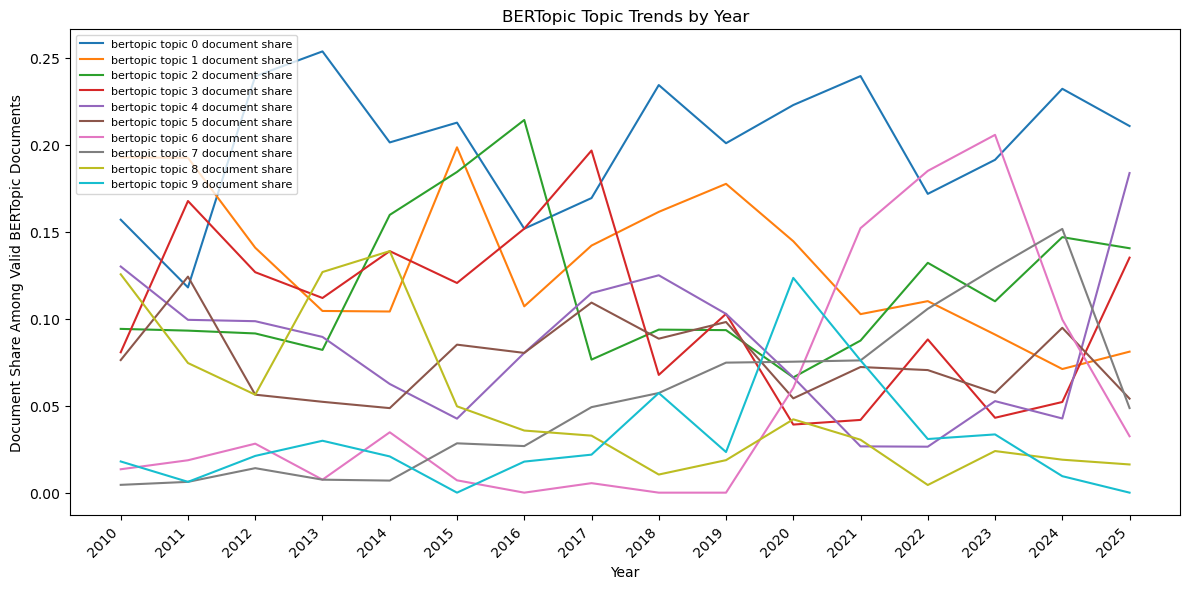

In [150]:
# Plot the top BERTopic topic trends by year.
plot_lines(
    bertopic_topic_trend_by_year,
    'year',
    bertopic_topic_trend_cols,
    'BERTopic Topic Trends by Year',
    'Document Share Among Valid BERTopic Documents',
    'bertopic_topic_trends_by_year.png',
    top_n=10
)

# 9. Model Evaluation

## 9.1. Initial Settings

In [151]:
EVALUATION_TOP_N_WORDS = TOPIC_TOP_N_WORDS
EVALUATION_REPRESENTATIVE_DOCUMENTS = REPRESENTATIVE_DOCUMENTS
EVALUATION_LABEL_WORD_COUNT = 5

In [152]:
# Store the final topic, word tables and representative documents for all three models.
final_model_topic_word_doc_sources = [
    ('NMF', nmf_topic_words, nmf_representative_documents),
    ('LDA', lda_topic_words, lda_representative_documents),
    ('BERTopic', bertopic_topic_words, bertopic_representative_documents),
]

## 9.2. Helper Functions

In [153]:
def model_evaluation_results(
    evaluation_df,
    parameter_col,
    selected_parameter_value
):

    # Add common comparison columns to a model evaluation table.
    return evaluation_df.assign(
        tuning_parameter=parameter_col,
        parameter_value=evaluation_df[parameter_col],
        selected_parameter_value=selected_parameter_value,
        is_selected_model=evaluation_df[parameter_col].eq(selected_parameter_value)
    )


In [154]:
def suggest_topic_label(topic_words, label_word_count=EVALUATION_LABEL_WORD_COUNT):

    # Select the first few topic words to create a readable topic label.
    label_words = [
        str(word).replace('_', ' ').strip().title()
        for word in topic_words[:label_word_count]
    ]

    # Join the words into one label.
    return ' / '.join(label_words)

In [155]:
def build_topic_words_table(model_name, topic_words_df):

    # Extract top words by topic.
    topic_word_lists = extract_top_words_by_topic(topic_words_df, top_n=TOPIC_TOP_N_WORDS)

    # Build a topic-word inspection table.
    return pd.DataFrame([
        {
            'model': model_name,
            'topic': topic,
            'top_words': ', '.join(words)
        }
        for topic, words in topic_word_lists.items()
    ])

In [156]:
def build_topic_label_suggestions(
    model_name,
    topic_words_df,
    representative_documents_df,
    top_n=10,
    label_word_count=4,
    representative_documents=5
):

    # Extract top words for each topic.
    topic_word_lists = extract_top_words_by_topic(topic_words_df, top_n=top_n)

    # Keep a copy of representative documents for the selected model.
    representative_docs = representative_documents_df.copy()

    # Create container to store one output row per topic.
    rows = []

    # Process each topic.
    for topic, topic_words in topic_word_lists.items():

        # Select representative documents for the current topic.
        topic_representatives = representative_docs.loc[
            representative_docs['topic'].eq(topic)
        ].sort_values('rank')

        # Extract clean representative document titles.
        representative_titles = (
            topic_representatives['title']
            .str.strip()
            .head(representative_documents)
            .tolist()
        )

        # Extract dictionary-based policy categories for representative documents.
        policy_categories_for_topic = (
            topic_representatives['dominant_policy_category']
            .str.strip()
        )

        # Use the most common policy category
        common_policy_category = policy_categories_for_topic.mode().iloc[0]

        # Add one topic-label suggestion row.
        rows.append({
            'model': model_name,
            'topic': topic,
            'suggested_label': suggest_topic_label(topic_words, label_word_count=label_word_count),
            'top_words': ', '.join(topic_words),
            'representative_titles': ' | '.join(representative_titles),
            'common_dictionary_policy_category': common_policy_category
        })

     # Return the label suggestions as a dataframe.
    return pd.DataFrame(rows)

In [157]:
def create_topic_label_map(label_suggestions_df, model_name):

    # Keep label suggestions for one model.
    label_rows = label_suggestions_df.loc[label_suggestions_df['model'].eq(model_name)].copy()

    # Create a topic-to-label dictionary.
    return dict(zip(label_rows['topic'], label_rows['suggested_label']))

In [158]:
def map_topic_labels(series, label_map):

    # Standardize topic keys in the label map.
    label_map_by_key = {
        topic: label
        for topic, label in label_map.items()
    }

    # Map topic IDs to readable labels.
    return series.map(lambda value: label_map_by_key[value])

In [159]:
def compare_topic_dictionary_trends(
    model_name,
    topic_trend_df,
    dictionary_trend_df,
    period_col,
    topic_cols
):

    # Find dictionary-based policy trend columns.
    dictionary_metric_cols = [
        col
        for col in dictionary_trend_df.columns
        if col.endswith('_avg_rate_per_1000_tokens')
    ]

    # Merge topic trends with dictionary trends by period.
    merged_trends = topic_trend_df[[period_col] + topic_cols].merge(
        dictionary_trend_df[[period_col] + dictionary_metric_cols],
        on=period_col,
        how='inner'
    )

    # Create container to store one row for each topic-policy correlation.
    rows = []

    # Compare each topic trend with each dictionary policy trend.
    for topic_col in topic_cols:
        for dictionary_metric_col in dictionary_metric_cols:
            
            rows.append({
                'model': model_name,
                'period_col': period_col,
                'topic_col': topic_col,
                'policy_category': dictionary_metric_col.replace('_avg_rate_per_1000_tokens', ''),
                'dictionary_metric_col': dictionary_metric_col,
                'correlation': merged_trends[topic_col].corr(merged_trends[dictionary_metric_col]),
            })

    return pd.DataFrame(rows)

In [160]:
def best_topic_dictionary_matches(correlation_df):

    # Remove rows with missing correlations.
    valid_correlations = correlation_df.dropna(subset=['correlation']).copy()

    # Keep the strongest positive correlation for each topic.
    return (
        valid_correlations
        .sort_values(
            ['model', 'period_col', 'topic_col', 'correlation'], 
            ascending=[True, True, True, False]
        )
        .groupby(
            ['model', 'period_col', 'topic_col'], 
            as_index=False
        )
        .head(1)
        .reset_index(drop=True)
    )

## 9.3. Compare Model metrics

In [161]:
# Prepare model evaluation results for comparison.
nmf_evaluation_results = model_evaluation_results(
    nmf_topic_number_evaluation,
    'n_topics',
    NMF_TOPIC_COUNT
)

lda_evaluation_results = model_evaluation_results(
    lda_topic_number_evaluation,
    'n_topics',
    LDA_TOPIC_COUNT
)

bertopic_evaluation_results = model_evaluation_results(
    bertopic_min_topic_size_evaluation,
    'min_topic_size',
    BERTOPIC_MIN_TOPIC_SIZE
)

In [162]:
# Define the column order for the model comparison table.
model_eval_cols = [
    'model',
    'tuning_parameter',
    'parameter_value',
    'selected_parameter_value',
    'is_selected_model',
    'min_topic_size',
    'n_topics',
    f'topic_diversity_top{EVALUATION_TOP_N_WORDS}',
    f'coherence_c_v_top{EVALUATION_TOP_N_WORDS}',
    'avg_max_document_topic_probability',
    'min_topic_prevalence',
    'max_topic_prevalence',
    'low_prevalence_topics',
    'topic_redundancy_mean',
    'high_redundancy_topic_pairs',

    # Model specific metrics
    'reconstruction_error',     # NMF
    'perplexity',               # LDA 
    'log_likelihood',
    'n_outlier_documents',      # BERTopic
    'outlier_share',
    'max_valid_topic_size',
    'min_valid_topic_size',
    'median_valid_topic_size',

    # Policy-topic alignment
    'avg_best_policy_topic_alignment'
]

In [163]:
# Combine NMF, LDA, and BERTopic evaluation results.
model_evaluation_comparison = pd.concat(
    [nmf_evaluation_results,
     lda_evaluation_results,
     bertopic_evaluation_results],
    ignore_index=True,
    sort=False
).reindex(columns=model_eval_cols)

save_table(model_evaluation_comparison, 'model_evaluation_comparison.csv')

In [164]:
model_evaluation_comparison

,model,tuning_parameter,parameter_value,selected_parameter_value,is_selected_model,min_topic_size,n_topics,topic_diversity_top10,coherence_c_v_top10,avg_max_document_topic_probability,...,high_redundancy_topic_pairs,reconstruction_error,perplexity,log_likelihood,n_outlier_documents,outlier_share,max_valid_topic_size,min_valid_topic_size,median_valid_topic_size,avg_best_policy_topic_alignment
0,NMF,n_topics,5,18,False,NaN,5,0.980000,0.684881,0.655979,...,0,51.995424,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.332876
1,NMF,n_topics,8,18,False,NaN,8,0.950000,0.741589,0.632351,...,0,51.027256,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.473062
2,NMF,n_topics,10,18,False,NaN,10,0.920000,0.735609,0.606394,...,0,50.515230,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.541077
3,NMF,n_topics,12,18,False,NaN,12,0.916667,0.732114,0.593739,...,0,50.082477,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.591683
4,NMF,n_topics,15,18,False,NaN,15,0.913333,0.748117,0.584736,...,0,49.441230,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.658823
5,NMF,n_topics,18,18,True,NaN,18,0.911111,0.750883,0.560864,...,0,48.959753,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.704047
6,NMF,n_topics,20,18,False,NaN,20,0.905000,0.729300,0.542643,...,0,48.657538,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.738556
7,NMF,n_topics,25,18,False,NaN,25,0.864000,0.725835,0.531326,...,0,48.012939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.739124
8,LDA,n_topics,5,20,False,NaN,5,0.880000,0.520059,0.754389,...,0,NaN,1588.351798,-4.537803e+06,NaN,NaN,NaN,NaN,NaN,0.374776
9,LDA,n_topics,8,20,False,NaN,8,0.800000,0.576331,0.676083,...,0,NaN,1476.307138,-4.492765e+06,NaN,NaN,NaN,NaN,NaN,0.445415


## 9.4. Selected Model Summary

In [165]:
# Keep only the selected final model for each model.
selected_model_evaluation = (
    model_evaluation_comparison
    .loc[model_evaluation_comparison['is_selected_model']]
    .drop(columns=['selected_parameter_value', 'is_selected_model'])
    .reset_index(drop=True)
)

save_table(selected_model_evaluation, 'selected_model_evaluation.csv')

In [166]:
selected_model_evaluation

,model,tuning_parameter,parameter_value,min_topic_size,n_topics,topic_diversity_top10,coherence_c_v_top10,avg_max_document_topic_probability,min_topic_prevalence,max_topic_prevalence,...,high_redundancy_topic_pairs,reconstruction_error,perplexity,log_likelihood,n_outlier_documents,outlier_share,max_valid_topic_size,min_valid_topic_size,median_valid_topic_size,avg_best_policy_topic_alignment
0,NMF,n_topics,18,NaN,18,0.911111,0.750883,0.560864,0.026868,0.109092,...,0,48.959753,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.704047
1,LDA,n_topics,20,NaN,20,0.765000,0.596297,0.641309,0.019205,0.127794,...,0,NaN,1166.188822,-4.347587e+06,NaN,NaN,NaN,NaN,NaN,0.590656
2,BERTopic,min_topic_size,100,100.0,10,0.980000,0.668558,0.623564,0.037097,0.202083,...,0,NaN,NaN,NaN,296.0,0.096323,621.0,114.0,242.0,0.485333


## 9.5. Inspect Top Words for Each Topic

In [167]:
# Combine top-word inspection table for each model.
model_topic_top_words_inspection = pd.concat(
    [build_topic_words_table(model_name, topic_words_df)
     for model_name, topic_words_df, _ in final_model_topic_word_doc_sources],
    ignore_index=True
)

save_table(model_topic_top_words_inspection, 'model_topic_top_words_inspection.csv')

In [168]:
model_topic_top_words_inspection

,model,topic,top_words
0,NMF,0,"broadband, rural, speed, caf, area, support, a..."
1,NMF,1,"school, library, student, funding, support, ap..."
2,NMF,2,"robocall, illegal, call, scam, consumer, calle..."
3,NMF,3,"serve, join, work, degree, law, role, policy, ..."
4,NMF,4,"consider, item, draft, meeting, question, sche..."
5,NMF,5,"spectrum, band, ghz, use, wireless, mhz, megah..."
6,NMF,6,"auction, bid, bidder, bidding, phase, win, 5_g..."
7,NMF,7,"patient, care, health, telehealth, award, covi..."
8,NMF,8,"911, outage, center, call, location, emergency..."
9,NMF,9,"consumer, charge, customer, bill, carrier, com..."


## 9.6. Inspect Representative Documents for Each Topic

In [169]:
# Combine representative documents from all three models.
combined_representative_documents = pd.concat(
    [nmf_representative_documents,
     lda_representative_documents,
     bertopic_representative_documents],
    ignore_index=True
)

In [170]:
# Define the columns to keep in the inspection table.
representative_documents_cols = [
    'model',
    'topic',
    'rank',
    'topic_probability',
    'filename',
    'title',
    'year',
    'dominant_policy_category',
    'dominant_policy_category_score',
    'matched_dictionary_terms',
    'text_preview',
]

In [171]:
# Select relevant columns, sort the rows, and save the table.
model_representative_documents_inspection = (
    combined_representative_documents[representative_documents_cols]
    .sort_values(['model', 'topic', 'rank'])
    .reset_index(drop=True)
)

save_table(model_representative_documents_inspection, 'model_representative_documents_inspection.csv')

In [172]:
model_representative_documents_inspection

,model,topic,rank,topic_probability,filename,title,year,dominant_policy_category,dominant_policy_category_score,matched_dictionary_terms,text_preview
0,BERTopic,0,1,1.000000,100121_FCC_Announces_Tentative_Agenda_for_Febr...,FCC Announces Tentative Agenda for February 11...,2010,schools_libraries,62.500000,affordability: usf | broadband: national_broad...,Federal Communications Commission Chairman Jul...
1,BERTopic,0,2,1.000000,251125_FCC_Announces_Tentative_Agenda_for_Dece...,FCC Announces Tentative Agenda for December Op...,2025,media_broadcasting,38.216561,media_broadcasting: lptv (3); broadcaster; tel...,Federal Communications Commission Chairman Bre...
2,BERTopic,0,3,1.000000,100223_FCC_ANNOUNCES_TENTATIVE_AGENDA_FOR_MARC...,FCC ANNOUNCES TENTATIVE AGENDA FOR MARCH 16TH ...,2010,broadband,138.888889,broadband: broadband (3); national_broadband_p...,Federal Communications Commission Chairman Jul...
3,BERTopic,0,4,1.000000,100317_COMMISSION_ANNOUNCES_BETA_LAUNCH_OF_SPE...,"COMMISSION ANNOUNCES ""BETA"" LAUNCH OF SPECTRUM...",2010,spectrum_wireless,157.360406,accessibility: tty | broadband: broadband (2);...,"Today, the Federal Communications Commission a..."
4,BERTopic,0,5,1.000000,100426_FCC_CHAIRMAN_JULIUS_GENACHOWSKI_ANNOUNC...,FCC CHAIRMAN JULIUS GENACHOWSKI ANNOUNCES LAUN...,2010,spectrum_wireless,147.058824,broadband: national_broadband_plan (2); broadb...,"Today, Federal Communications Commission Chair..."
...,...,...,...,...,...,...,...,...,...,...,...
235,NMF,17,1,1.000000,200930_FCC_Reforms_IP_Captioned_Telephone_Serv...,FCC Reforms IP Captioned Telephone Service Rates,2020,accessibility,148.148148,accessibility: trs (11); ip_cts (8); captionin...,The FCC today took action to ensure that high-...
236,NMF,17,2,1.000000,230928_FCC_Increases_Video_Relay_Service_Suppo...,FCC Increases Video Relay Service Support & Up...,2023,accessibility,121.212121,accessibility: vrs (13); trs (3); asl (3); dis...,The Federal Communications Commission on Septe...
237,NMF,17,3,1.000000,110406_TRS_FUND_ADMINISTRATOR_NAMED.txt,TRS FUND ADMINISTRATOR NAMED,2011,accessibility,140.243902,accessibility: trs (20); disability (2); cvaa ...,The Commission has awarded Rolka Loube Saltzer...
238,NMF,17,4,0.996342,210520_FCC_Seeks_Comment_on_Compensation_Plan_...,FCC Seeks Comment on Compensation Plan for Vid...,2021,accessibility,99.236641,accessibility: vrs (10); trs (3),The FCC took action today in its role overseei...


## 9.7. Assign Human-Readable Topic Labels

In [173]:
# Build topic label suggestions for each model.
model_topic_label_suggestions = pd.concat(
    [build_topic_label_suggestions(
            model_name,
            topic_words_df,
            representative_documents_df,
            top_n=EVALUATION_TOP_N_WORDS,
            label_word_count=EVALUATION_LABEL_WORD_COUNT,
            representative_documents=EVALUATION_REPRESENTATIVE_DOCUMENTS
        )
        for model_name, topic_words_df, representative_documents_df in final_model_topic_word_doc_sources],
    ignore_index=True
)

save_table(model_topic_label_suggestions, 'model_topic_label_suggestions.csv')

In [174]:
model_topic_label_suggestions

,model,topic,suggested_label,top_words,representative_titles,common_dictionary_policy_category
0,NMF,0,Broadband / Rural / Speed / Caf / Area,"broadband, rural, speed, caf, area, support, a...",CenturyLink Accepts $506 M from Connect Americ...,broadband
1,NMF,1,School / Library / Student / Funding / Support,"school, library, student, funding, support, ap...",FCC Announces Over $21 Million in Emergency Co...,schools_libraries
2,NMF,2,Robocall / Illegal / Call / Scam / Consumer,"robocall, illegal, call, scam, consumer, calle...",FCC Issues Latest Cease & Desist Robocall Warn...,consumer_privacy
3,NMF,3,Serve / Join / Work / Degree / Law,"serve, join, work, degree, law, role, policy, ...",Matthew DelNero Named Deputy Chief of Wireline...,competition
4,NMF,4,Consider / Item / Draft / Meeting / Question,"consider, item, draft, meeting, question, sche...",FCC Announces Tentative Agenda for February Op...,compliance
5,NMF,5,Spectrum / Band / Ghz / Use / Wireless,"spectrum, band, ghz, use, wireless, mhz, megah...",FCC Proposes 40 MHz of Additional Spectrum for...,spectrum_wireless
6,NMF,6,Auction / Bid / Bidder / Bidding / Phase,"auction, bid, bidder, bidding, phase, win, 5_g...",FCC Announces Clock Phase of Auction 102 Concl...,spectrum_wireless
7,NMF,7,Patient / Care / Health / Telehealth / Award,"patient, care, health, telehealth, award, covi...",FCC Approves Twelfth Set of COVID-19 Telehealt...,telehealth
8,NMF,8,911 / Outage / Center / Call / Location,"911, outage, center, call, location, emergency...",FCC Adopts Rules to Improve Wireless 911 Call ...,public_safety
9,NMF,9,Consumer / Charge / Customer / Bill / Carrier,"consumer, charge, customer, bill, carrier, com...",FCC Adopts Rules to Help Consumers Identify an...,compliance


In [175]:
model_list = ['NMF', 'LDA', 'BERTopic']

for model in model_list:

    # Create topic-label maps for each model.
    topic_label_map = create_topic_label_map(model_topic_label_suggestions, model)

    model_lower = model.lower()

    # Add readable topic labels to the main dataframe.
    df[f'dominant_{model_lower}_topic_label'] = (
        df[f'dominant_{model_lower}_topic'].map(topic_label_map)
    )

## 9.8. Compare Topic Trends with Policy Focus Trends

In [176]:
# Create BERTopic topic-share column names.
bertopic_topic_cols = [
    f'bertopic_topic_{topic_id}_document_share'
    for topic_id in bertopic_topic_ids
]

In [177]:
# Compare topic trends with dictionary-based policy trends by year.
topic_dictionary_trend_correlations_by_year = pd.concat(
    [
        compare_topic_dictionary_trends(
            'NMF',
            nmf_topic_trend_by_year,
            dictionary_policy_trend_by_year,
            'year',
            nmf_topic_cols
        ),
        compare_topic_dictionary_trends(
            'LDA',
            lda_topic_trend_by_year,
            dictionary_policy_trend_by_year,
            'year',
            lda_topic_cols
        ),
        compare_topic_dictionary_trends(
            'BERTopic',
            bertopic_topic_trend_by_year,
            dictionary_policy_trend_by_year,
            'year',
            bertopic_topic_cols
        ),
    ],
    ignore_index=True
)

# Find the strongest dictionary match for each topic by year.
topic_dictionary_trend_best_matches_by_year = best_topic_dictionary_matches(
    topic_dictionary_trend_correlations_by_year
)

save_table(topic_dictionary_trend_correlations_by_year, 'topic_dictionary_trend_correlations_by_year.csv')
save_table(topic_dictionary_trend_best_matches_by_year, 'topic_dictionary_trend_best_matches_by_year.csv')

In [178]:
topic_dictionary_trend_best_matches_by_year

,model,period_col,topic_col,policy_category,dictionary_metric_col,correlation
0,BERTopic,year,bertopic_topic_0_document_share,spectrum_wireless,spectrum_wireless_avg_rate_per_1000_tokens,0.678238
1,BERTopic,year,bertopic_topic_1_document_share,broadband,broadband_avg_rate_per_1000_tokens,0.686498
2,BERTopic,year,bertopic_topic_2_document_share,compliance,compliance_avg_rate_per_1000_tokens,0.740523
3,BERTopic,year,bertopic_topic_3_document_share,competition,competition_avg_rate_per_1000_tokens,0.711018
4,BERTopic,year,bertopic_topic_4_document_share,media_broadcasting,media_broadcasting_avg_rate_per_1000_tokens,0.494584
5,BERTopic,year,bertopic_topic_5_document_share,public_safety,public_safety_avg_rate_per_1000_tokens,0.424990
6,BERTopic,year,bertopic_topic_6_document_share,schools_libraries,schools_libraries_avg_rate_per_1000_tokens,0.952614
7,BERTopic,year,bertopic_topic_7_document_share,consumer_privacy,consumer_privacy_avg_rate_per_1000_tokens,0.957806
8,BERTopic,year,bertopic_topic_8_document_share,accessibility,accessibility_avg_rate_per_1000_tokens,0.949923
9,BERTopic,year,bertopic_topic_9_document_share,telehealth,telehealth_avg_rate_per_1000_tokens,0.961997


In [179]:
# Compare topic trends with dictionary-based policy trends by quarter.
topic_dictionary_trend_correlations_by_quarter = pd.concat(
    [
        compare_topic_dictionary_trends(
            'NMF',
            nmf_topic_trend_by_quarter,
            dictionary_policy_trend_by_quarter,
            'quarter',
            nmf_topic_cols
        ),
        compare_topic_dictionary_trends(
            'LDA',
            lda_topic_trend_by_quarter,
            dictionary_policy_trend_by_quarter,
            'quarter',
            lda_topic_cols
        ),
        compare_topic_dictionary_trends(
            'BERTopic',
            bertopic_topic_trend_by_quarter,
            dictionary_policy_trend_by_quarter,
            'quarter',
            bertopic_topic_cols
        ),
    ],
    ignore_index=True
)

# Find the strongest dictionary match for each topic by quarter.
topic_dictionary_trend_best_matches_by_quarter = best_topic_dictionary_matches(
    topic_dictionary_trend_correlations_by_quarter
)

save_table(topic_dictionary_trend_correlations_by_quarter, 'topic_dictionary_trend_correlations_by_quarter.csv')
save_table(topic_dictionary_trend_best_matches_by_quarter, 'topic_dictionary_trend_best_matches_by_quarter.csv')

In [180]:
topic_dictionary_trend_best_matches_by_quarter

,model,period_col,topic_col,policy_category,dictionary_metric_col,correlation
0,BERTopic,quarter,bertopic_topic_0_document_share,spectrum_wireless,spectrum_wireless_avg_rate_per_1000_tokens,0.596231
1,BERTopic,quarter,bertopic_topic_1_document_share,broadband,broadband_avg_rate_per_1000_tokens,0.699621
2,BERTopic,quarter,bertopic_topic_2_document_share,compliance,compliance_avg_rate_per_1000_tokens,0.441008
3,BERTopic,quarter,bertopic_topic_3_document_share,competition,competition_avg_rate_per_1000_tokens,0.326904
4,BERTopic,quarter,bertopic_topic_4_document_share,media_broadcasting,media_broadcasting_avg_rate_per_1000_tokens,0.609906
5,BERTopic,quarter,bertopic_topic_5_document_share,public_safety,public_safety_avg_rate_per_1000_tokens,0.719668
6,BERTopic,quarter,bertopic_topic_6_document_share,schools_libraries,schools_libraries_avg_rate_per_1000_tokens,0.919175
7,BERTopic,quarter,bertopic_topic_7_document_share,consumer_privacy,consumer_privacy_avg_rate_per_1000_tokens,0.893867
8,BERTopic,quarter,bertopic_topic_8_document_share,accessibility,accessibility_avg_rate_per_1000_tokens,0.877440
9,BERTopic,quarter,bertopic_topic_9_document_share,telehealth,telehealth_avg_rate_per_1000_tokens,0.932210


In [181]:
# Combine yearly and quarterly best matches.
topic_dictionary_trend_best_matches_combined = pd.concat(
    [
        topic_dictionary_trend_best_matches_by_year,
        topic_dictionary_trend_best_matches_by_quarter,
    ],
    ignore_index=True
)

save_table(topic_dictionary_trend_best_matches_combined, 'topic_dictionary_trend_best_matches_combined.csv')

In [182]:
topic_dictionary_trend_best_matches_combined

,model,period_col,topic_col,policy_category,dictionary_metric_col,correlation
0,BERTopic,year,bertopic_topic_0_document_share,spectrum_wireless,spectrum_wireless_avg_rate_per_1000_tokens,0.678238
1,BERTopic,year,bertopic_topic_1_document_share,broadband,broadband_avg_rate_per_1000_tokens,0.686498
2,BERTopic,year,bertopic_topic_2_document_share,compliance,compliance_avg_rate_per_1000_tokens,0.740523
3,BERTopic,year,bertopic_topic_3_document_share,competition,competition_avg_rate_per_1000_tokens,0.711018
4,BERTopic,year,bertopic_topic_4_document_share,media_broadcasting,media_broadcasting_avg_rate_per_1000_tokens,0.494584
...,...,...,...,...,...,...
91,NMF,quarter,nmf_topic_5,spectrum_wireless,spectrum_wireless_avg_rate_per_1000_tokens,0.757802
92,NMF,quarter,nmf_topic_6,spectrum_wireless,spectrum_wireless_avg_rate_per_1000_tokens,0.746059
93,NMF,quarter,nmf_topic_7,telehealth,telehealth_avg_rate_per_1000_tokens,0.976103
94,NMF,quarter,nmf_topic_8,public_safety,public_safety_avg_rate_per_1000_tokens,0.761854


## 9.9. Final Evaluation Summary Table

In [183]:
# Count representative documents for each model.
representative_counts = (
    model_representative_documents_inspection
    .groupby('model')
    .size()
    .rename('n_representative_documents')
    .reset_index()
)

In [184]:
# Count suggested topic labels for each model.
label_counts = (
    model_topic_label_suggestions
    .groupby('model')['topic']
    .nunique()
    .rename('n_topic_labels')
    .reset_index()
)

In [185]:
# Calculate average topic-dictionary trend correlation for each model.
trend_alignment = (
    topic_dictionary_trend_best_matches_combined
    .groupby('model')['correlation']
    .mean()
    .rename('avg_dictionary_trend_correlation')
    .reset_index()
)

In [186]:
# Merge all final evaluation components into one summary table.
model_evaluation_final = (
    selected_model_evaluation
    .merge(representative_counts, on='model', how='left')
    .merge(label_counts, on='model', how='left')
    .merge(trend_alignment, on='model', how='left')
)

save_table(model_evaluation_final, 'model_evaluation_final.csv')

In [187]:
model_evaluation_final

,model,tuning_parameter,parameter_value,min_topic_size,n_topics,topic_diversity_top10,coherence_c_v_top10,avg_max_document_topic_probability,min_topic_prevalence,max_topic_prevalence,...,log_likelihood,n_outlier_documents,outlier_share,max_valid_topic_size,min_valid_topic_size,median_valid_topic_size,avg_best_policy_topic_alignment,n_representative_documents,n_topic_labels,avg_dictionary_trend_correlation
0,NMF,n_topics,18,NaN,18,0.911111,0.750883,0.560864,0.026868,0.109092,...,NaN,NaN,NaN,NaN,NaN,NaN,0.704047,90,18,0.738705
1,LDA,n_topics,20,NaN,20,0.765000,0.596297,0.641309,0.019205,0.127794,...,-4.347587e+06,NaN,NaN,NaN,NaN,NaN,0.590656,100,20,0.643476
2,BERTopic,min_topic_size,100,100.0,10,0.980000,0.668558,0.623564,0.037097,0.202083,...,NaN,296.0,0.096323,621.0,114.0,242.0,0.485333,50,10,0.728711


## 9.10. Save the final data file

In [188]:
def save_table_parquet(dataframe, filename):
    path = TABLE_DIR / filename
    dataframe.to_parquet(path, index=False)

In [189]:
save_table(df, 'final_data.csv')

In [190]:
save_table_parquet(df, 'final_data.parquet')